# Regress trace element concentrations vs growth and environment

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [71]:
# Load necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

### Read data from all specimens

In [72]:
# Load all files from the folder
folder_path = "TE_data_with_GR_T_S/"
all_data = pd.DataFrame()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        # Read each file
        file_data = pd.read_csv(
            os.path.join(folder_path, file),
            dtype={ # Convert mixed columns to object type
                'T_timing_1': "a",
                'T_timing_2': "a",
                'T_timing_3': "a",
                'T_timing_4': "a",
                'T_std_timing_1': "a",
                'T_std_timing_2': "a",
                'T_std_timing_3': "a",
                'T_std_timing_4': "a",
                'S_timing_1' : "a",
                'S_timing_2' : "a",
                'S_timing_3' : "a",
                'S_timing_4' : "a",
                'S_std_timing_1': "a",
                'S_std_timing_2': "a",
                'S_std_timing_3': "a",
                'S_std_timing_4': "a"
            },
            index_col=0
        )
        # Add a column for the specimen name
        file_data['specimen'] = file.split('_')[0]  # Specimen name is the first part of the filename
        # Add column separating subtidal vs intertidal treatments
        file_data['treatment'] = 'intertidal' if file.split('_')[1] == 'int' else 'subtidal' if file.split('_')[1] == 'sub' else 'unknown'
        # Concatenate into a single DataFrame
        all_data = pd.concat([all_data, file_data], ignore_index=True)

# For the element columns, replace all zero values with NaN to avoid skewing the analysis
element_columns = ['23Na/43Ca', '25Mg/43Ca', '43Ca/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
all_data[element_columns] = all_data[element_columns].replace(0, np.nan)

# Display the first few rows of the combined data
all_data.head()

,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,43Ca/43Ca,55Mn/43Ca,88Sr/43Ca,...,S_timing_3,S_std_timing_3,Chl_timing_3,T_timing_4,T_std_timing_4,S_timing_4,S_std_timing_4,Chl_timing_4,specimen,treatment
0,0.013676,62.33211,30944.10620,80703.27530,6301.588000,199.059248,1.253571,1000.0,0.306491,0.013676,...,25.485,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,intertidal
1,0.000000,62.44125,30944.46978,80703.01737,5301.123838,235.482235,3.406310,1000.0,0.347474,NaN,...,25.485,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,intertidal
2,0.019326,62.55040,30944.83337,80702.75945,4600.846556,284.331679,1.771388,1000.0,0.380053,0.019326,...,25.485,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,intertidal
3,0.037763,62.65955,30945.19695,80702.50152,5751.322804,221.307763,3.115197,1000.0,0.348871,0.037763,...,25.485,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,intertidal
4,0.013795,62.76871,30945.56053,80702.24359,6251.562891,205.558351,1.264443,1000.0,0.242893,0.013795,...,25.485,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,intertidal


### Clean combined dataframe

In [73]:
# Remove all unnamed columns
all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

# Convert temperature and salinity columns to numeric, coerce errors to NaN
all_data['T_timing_1'] = pd.to_numeric(all_data['T_timing_1'], errors='coerce')
all_data['T_timing_2'] = pd.to_numeric(all_data['T_timing_2'], errors='coerce')
all_data['T_timing_3'] = pd.to_numeric(all_data['T_timing_3'], errors='coerce')
all_data['T_timing_4'] = pd.to_numeric(all_data['T_timing_4'], errors='coerce')
all_data['T_std_timing_1'] = pd.to_numeric(all_data['T_std_timing_1'], errors='coerce')
all_data['T_std_timing_2'] = pd.to_numeric(all_data['T_std_timing_2'], errors='coerce')
all_data['T_std_timing_3'] = pd.to_numeric(all_data['T_std_timing_3'], errors='coerce')
all_data['T_std_timing_4'] = pd.to_numeric(all_data['T_std_timing_4'], errors='coerce')
all_data['S_timing_1'] = pd.to_numeric(all_data['S_timing_1'], errors='coerce')
all_data['S_timing_2'] = pd.to_numeric(all_data['S_timing_2'], errors='coerce')
all_data['S_timing_3'] = pd.to_numeric(all_data['S_timing_3'], errors='coerce')
all_data['S_timing_4'] = pd.to_numeric(all_data['S_timing_4'], errors='coerce')
all_data['S_std_timing_1'] = pd.to_numeric(all_data['S_std_timing_1'], errors='coerce')
all_data['S_std_timing_2'] = pd.to_numeric(all_data['S_std_timing_2'], errors='coerce')
all_data['S_std_timing_3'] = pd.to_numeric(all_data['S_std_timing_3'], errors='coerce')
all_data['S_std_timing_4'] = pd.to_numeric(all_data['S_std_timing_4'], errors='coerce')

# print dtypes of all columns
print(all_data.dtypes)

proxy_filtered    float64
time              float64
Xpos              float64
Ypos              float64
Ca43              float64
                   ...   
S_timing_4        float64
S_std_timing_4    float64
Chl_timing_4      float64
specimen           object
treatment          object
Length: 65, dtype: object


### Summarize elemental, growth and environmental values per specimen and per interval

In [74]:
# Summarize elemental, growth and environmental values per specimen, per interval and per age model choice, 
data_summary1 = all_data.groupby(['specimen', 'peakID_1', 'treatment']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered_peakID_1', 'mean'),
    growth_sd=('interval_growth_rate_centered_peakID_1', 'std'),
    T_mean=('T_timing_1', 'mean'),
    T_sd=('T_timing_1', 'std'),
    S_mean=('S_timing_1', 'mean'),
    S_sd=('S_timing_1', 'std'),
    Chl_mean=('Chl_timing_1', 'mean'),
    Chl_sd=("Chl_timing_1", 'std'),
    N=('23Na/43Ca', 'count')
).reset_index().rename(columns={'peakID_1': 'Interval'}) # Rename peakID_1 to peakID for consistency
data_summary1['peakID'] = 1  # Add a column to indicate timing option

data_summary2 = all_data.groupby(['specimen', 'peakID_2', 'treatment']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered_peakID_2', 'mean'),
    growth_sd=('interval_growth_rate_centered_peakID_2', 'std'),
    T_mean=('T_timing_2', 'mean'),
    T_sd=('T_timing_2', 'std'),
    S_mean=('S_timing_2', 'mean'),
    S_sd=('S_timing_2', 'std'),
    Chl_mean=('Chl_timing_2', 'mean'),
    Chl_sd=("Chl_timing_2", 'std'),
    N=('23Na/43Ca', 'count')
).reset_index().rename(columns={'peakID_2': 'Interval'})
data_summary2['peakID'] = 2  # Add a column to indicate timing option

data_summary3 = all_data.groupby(['specimen', 'peakID_3', 'treatment']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered_peakID_3', 'mean'),
    growth_sd=('interval_growth_rate_centered_peakID_3', 'std'),
    T_mean=('T_timing_3', 'mean'),
    T_sd=('T_timing_3', 'std'),
    S_mean=('S_timing_3', 'mean'),
    S_sd=('S_timing_3', 'std'),
    Chl_mean=('Chl_timing_3', 'mean'),
    Chl_sd=("Chl_timing_3", 'std'),
    N=('23Na/43Ca', 'count')
).reset_index().rename(columns={'peakID_3': 'Interval'})
data_summary3['peakID'] = 3  # Add a column to indicate timing option

data_summary4 = all_data.groupby(['specimen', 'peakID_4', 'treatment']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered_peakID_4', 'mean'),
    growth_sd=('interval_growth_rate_centered_peakID_4', 'std'),
    T_mean=('T_timing_4', 'mean'),
    T_sd=('T_timing_4', 'std'),
    S_mean=('S_timing_4', 'mean'),
    S_sd=('S_timing_4', 'std'),
    Chl_mean=('Chl_timing_4', 'mean'),
    Chl_sd=("Chl_timing_4", 'std'),
    N=('23Na/43Ca', 'count')
).reset_index().rename(columns={'peakID_4': 'Interval'})
data_summary4['peakID'] = 4  # Add a column to indicate timing option

# Display the first few rows of the summarized data
data_summary = pd.concat([data_summary1, data_summary2, data_summary3, data_summary4], ignore_index=True)
data_summary.head()

,specimen,Interval,treatment,NaCa_mean,NaCa_sd,MgCa_mean,MgCa_sd,MnCa_mean,MnCa_sd,SrCa_mean,...,growth_mean,growth_sd,T_mean,T_sd,S_mean,S_sd,Chl_mean,Chl_sd,N,peakID
0,B255,interval 0,intertidal,22.418515,12.146257,2.174624,12.851412,0.016784,0.087080,1.982095,...,21.223411,0.0,18.275547,3.298498,32.158171,1.122759,4.006749,1.284804,4052,1
1,B255,interval 1,intertidal,20.972428,5.119226,0.699002,0.184180,0.006499,0.001394,2.011312,...,165.907024,0.0,19.687835,0.623481,30.042496,0.768439,5.537160,2.496670,6413,1
2,B255,interval 2,intertidal,22.423598,5.459526,1.159564,0.293975,0.008481,0.001727,2.172779,...,77.435184,0.0,17.173557,1.073507,29.632051,0.776892,3.292953,2.507227,3623,1
3,B255,interval 3,intertidal,23.462455,4.528163,0.967798,0.209171,0.010317,0.001871,2.038598,...,153.541967,0.0,14.491394,1.163500,30.006246,0.844607,5.663160,3.133894,9455,1
4,B255,interval 4,intertidal,25.376972,4.137847,0.964359,0.168695,0.010173,0.001692,1.873337,...,101.487709,0.0,12.040293,0.757787,28.400431,1.278879,9.382970,2.583554,6167,1


### Export data summary

In [75]:
data_summary.to_csv("All_data_summary.csv", index=False)

## Exploratory data analysis

### Plot Pearson correlation matrix

  specimen    Interval   treatment  NaCa_mean    NaCa_sd  MgCa_mean  \
0     B255  interval 0  intertidal  22.418515  12.146257   2.174624   
1     B255  interval 1  intertidal  20.972428   5.119226   0.699002   
2     B255  interval 2  intertidal  22.423598   5.459526   1.159564   
3     B255  interval 3  intertidal  23.462455   4.528163   0.967798   
4     B255  interval 4  intertidal  25.376972   4.137847   0.964359   

     MgCa_sd  MnCa_mean   MnCa_sd  SrCa_mean  ...  growth_mean  growth_sd  \
0  12.851412   0.016784  0.087080   1.982095  ...    21.223411        0.0   
1   0.184180   0.006499  0.001394   2.011312  ...   165.907024        0.0   
2   0.293975   0.008481  0.001727   2.172779  ...    77.435184        0.0   
3   0.209171   0.010317  0.001871   2.038598  ...   153.541967        0.0   
4   0.168695   0.010173  0.001692   1.873337  ...   101.487709        0.0   

      T_mean      T_sd     S_mean      S_sd  Chl_mean    Chl_sd     N  peakID  
0  18.275547  3.298498  32.158

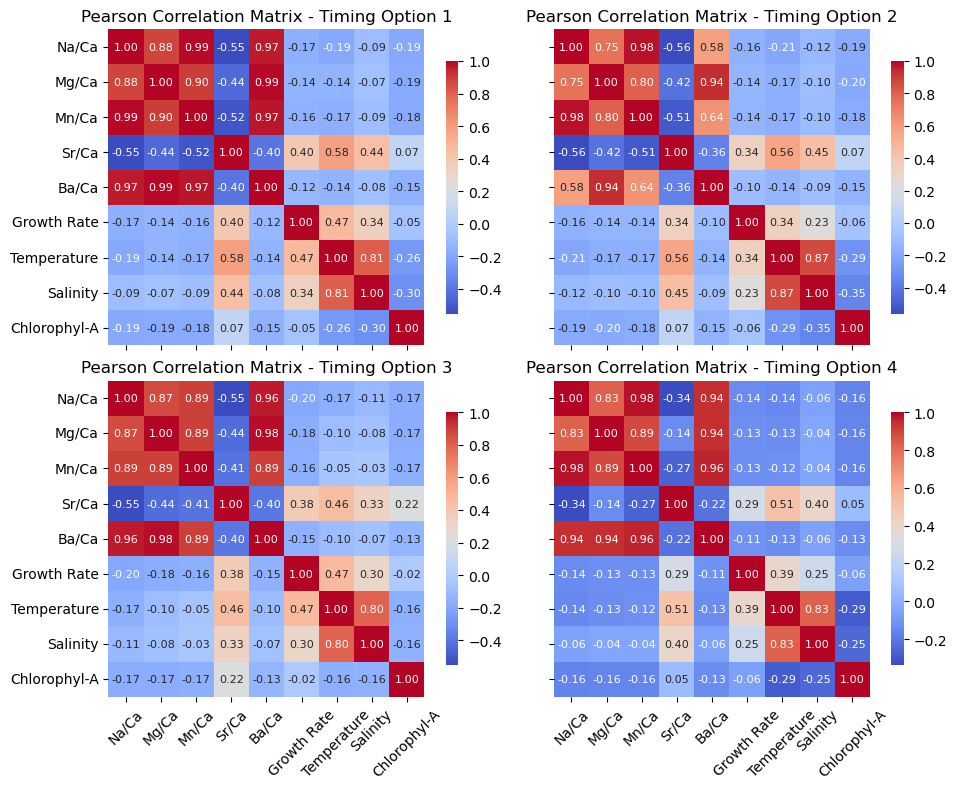

In [76]:
# Plot correlation matrix for data_summary
# Extract only data from the intervals, not the peaks
data_intervals = data_summary[~data_summary['Interval'].str.contains('peak', case=False, na=False)]
print(data_intervals.head())

# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]

# Plot correlation matrix for each timing option in 2x2 plotting grid
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axs.ravel()

for timing_option in range(1, 5):
    ax = axes[timing_option - 1]
    data_subset = data_intervals[data_intervals['peakID'] == timing_option]
    data_subset_trim = data_subset[correlation_columns]
    
    # Compute correlation and apply renamed labels
    corr = data_subset_trim.corr()
    corr.rename(index=all_display_names, columns=all_display_names, inplace=True)
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, annot_kws={"size":8}, ax=ax)
    ax.set_title(f'Pearson Correlation Matrix - Timing Option {timing_option}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### Visualize biggest difference in correlation between timings

Text(0.5, 1.0, 'Overall Pearson Correlation')

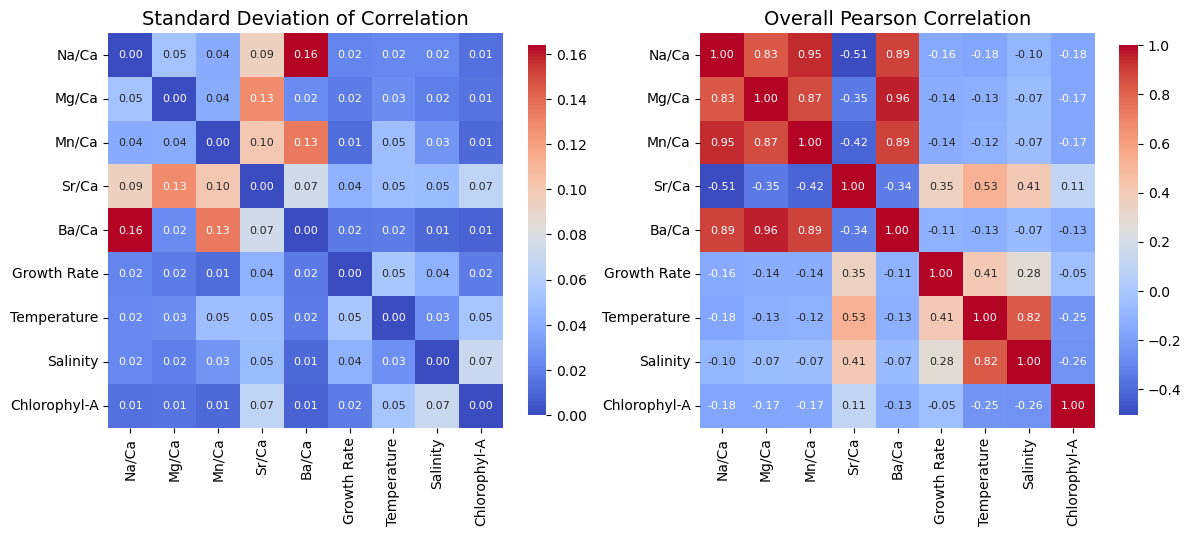

In [77]:
# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]

# Calculate overall correlation matrix combining all timing options
data_trim = data_intervals[correlation_columns]
corr = data_trim.corr()
corr.rename(index=all_display_names, columns=all_display_names, inplace=True)

# Calculate correlation matrices for all timing options and calculate standard deviation between correlation values
corr_matrices = []
for timing_option in range(1, 5):
    data_subset = data_intervals[data_intervals['peakID'] == timing_option]
    data_subset_trim = data_subset[correlation_columns]
    corr_subset = data_subset_trim.corr()
    corr_subset.rename(index=all_display_names, columns=all_display_names, inplace=True)
    corr_matrices.append(corr_subset)
corr_stack = np.stack([cm.values for cm in corr_matrices], axis=2)
corr_std = np.std(corr_stack, axis=2)
# Add back labels
corr_std = pd.DataFrame(corr_std, index=[all_display_names[col] for col in correlation_columns], columns=[all_display_names[col] for col in correlation_columns])

# Display overall correlation matrix and standard deviation matrix in two side-by-side panels
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(corr_std, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, annot_kws={"size":8})
plt.title('Standard Deviation of Correlation', fontsize=14)
plt.subplot(1, 2, 2)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, annot_kws={"size":8})
plt.title('Overall Pearson Correlation', fontsize=14)

### Plot Spearman correlation matrix

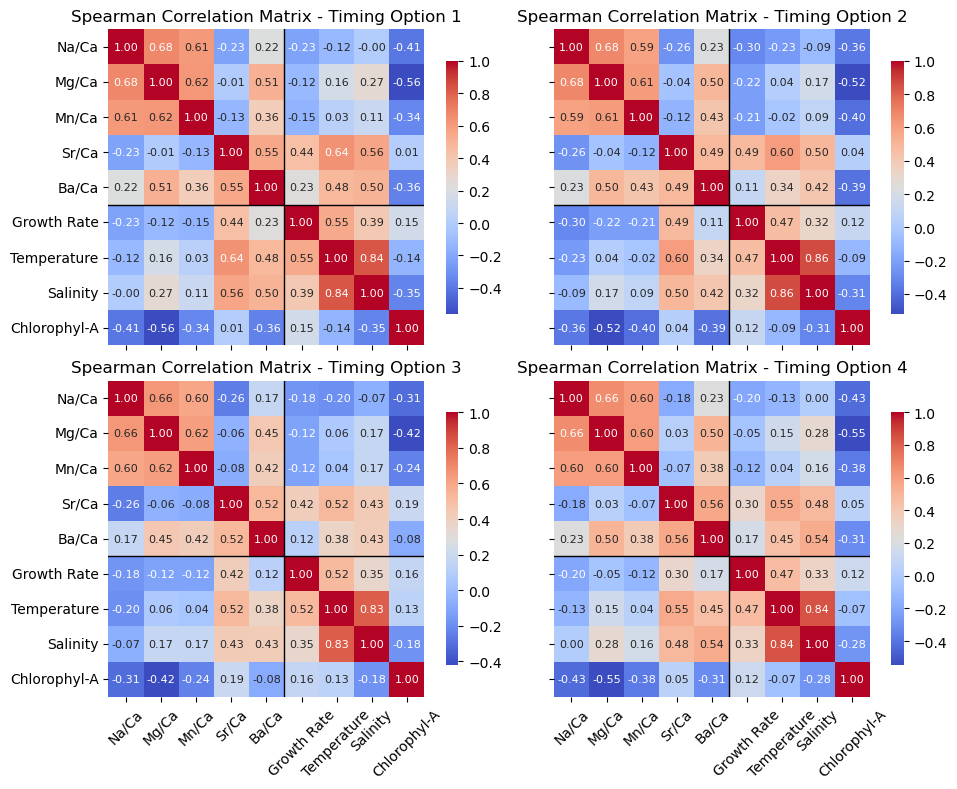

In [78]:
# Plot correlation matrix for data_intervals
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]

# Plot correlation matrix for each timing option in 2x2 plotting grid
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axs.ravel()

for timing_option in range(1, 5):
    ax = axes[timing_option - 1]
    data_subset = data_intervals[data_intervals['peakID'] == timing_option]
    data_subset_trim = data_subset[correlation_columns]
    
    # Compute correlation and apply renamed labels
    corr = data_subset_trim.corr(method = 'spearman')
    corr.rename(index=all_display_names, columns=all_display_names, inplace=True)
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, annot_kws={"size":8}, ax=ax)
    ax.set_title(f'Spearman Correlation Matrix - Timing Option {timing_option}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

    # Add lines to separate predictors and responses
    ax.axhline(5, color='black', linewidth=1)
    ax.axvline(5, color='black', linewidth=1)

plt.tight_layout()
plt.show()

### Pairwise scatter plots with errors and by-specimen statistics (all timing options combined)

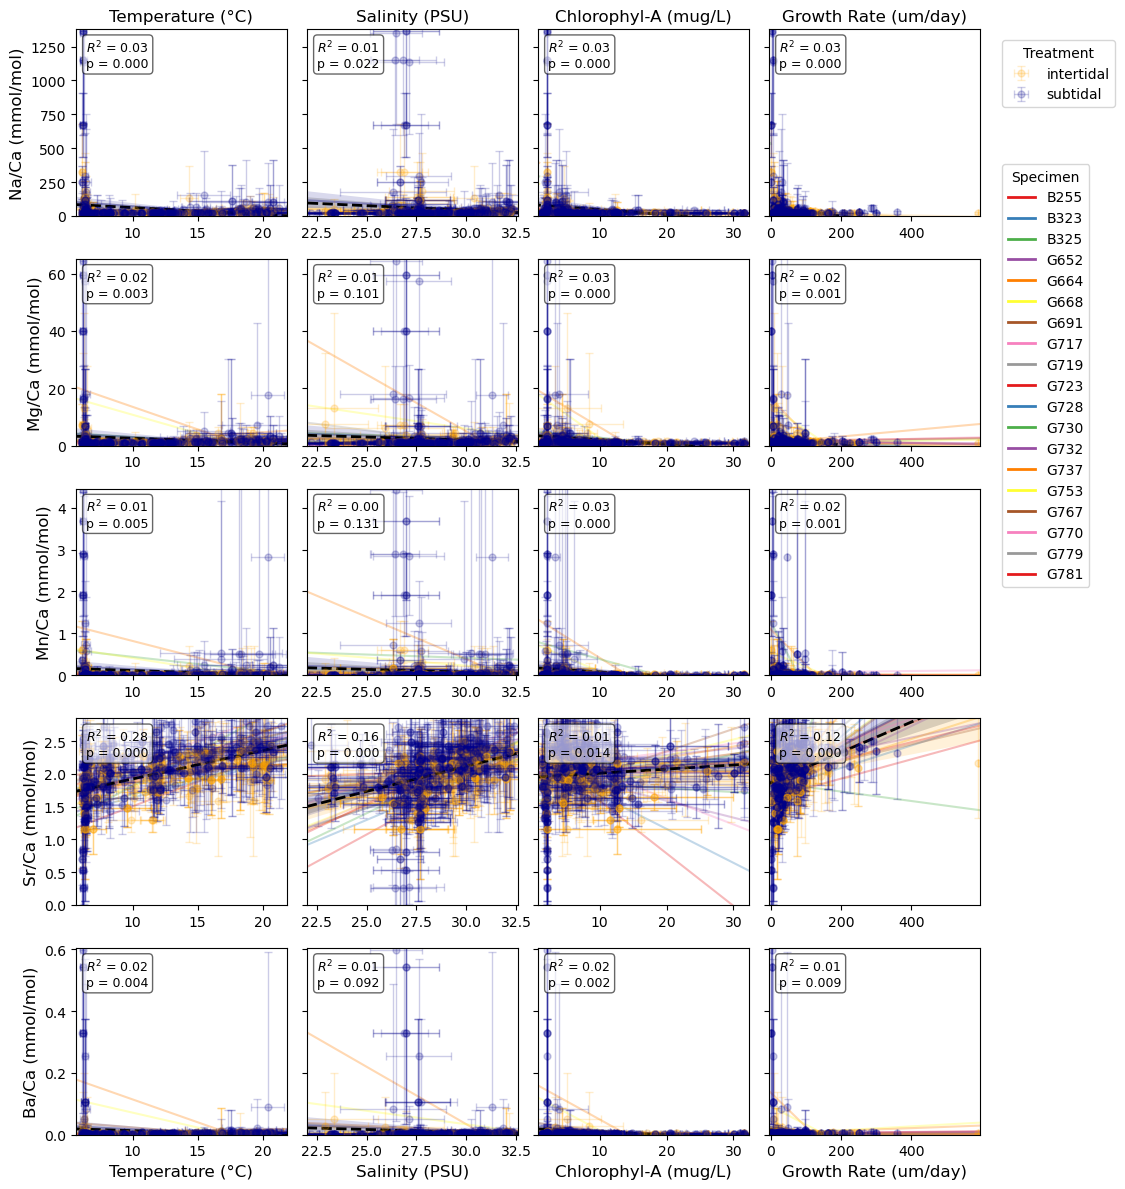

In [79]:
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_intervals['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Assign unique colors per treatment
treatments = data_intervals['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Store regression stats
global_stats_lin_all = {}      # global regression stats
specimen_stats_lin_all = {}    # regression stats per specimen
treatment_stats_lin_all = {}   # regression stats per treatment
peakID_stats_lin_all = {}      # regression stats per peakID (timing option)

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        # First plot per specimen
        for specimen in specimens:
            df_subset = data_intervals[data_intervals['specimen'] == specimen]
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'treatment': df_subset['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'treatment': df_subset['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }
        # Secondly, plot per treatment
        for treatment in treatments:
            df_subset = data_intervals[data_intervals['treatment'] == treatment] # Isolate data per treatment group
            # Set color for the treatment
            color = treatment_colors[treatment]

            # Compute and store treatment-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_lin_all[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                treatment_stats_lin_all[(response, predictor, treatment)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }

            # Extract x, y, and error values for the current specimen
            x = df_subset[predictor]
            y = df_subset[response]
            xerr = df_subset[predictor_names[predictor]]
            yerr = df_subset[response_names[response]]

            # Plot data points with error bars
            ax.errorbar(x,
                        y,
                        xerr=xerr,
                        yerr=yerr,
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.2,
                        markersize=5,
                        capsize=3,
                        label=treatment if (i == 0 and j == 0) else None  # only label once for legend
            )

            # Plot regression line per treatment
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=95,
                color=treatment_colors[treatment],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )
        # Now plot lines per peakID (timing option)
        for peakID in range(1, 5):
            df_subset = data_intervals[data_intervals['peakID'] == peakID]
            # Compute and store peakID-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                peakID_stats_lin_all[(response, predictor, peakID)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                peakID_stats_lin_all[(response, predictor, peakID)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }

        # Plot global regression line
        sns.regplot(
            x=predictor,
            y=response,
            data=data_intervals,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        df_reg = data_intervals[[predictor, response]].dropna()
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_all[(response, predictor)] = {
            'r2': r2,
            'p': pval,
            'n': len(df_reg),
            'slope': model.params[predictor],
            'slope_std_err': model.bse[predictor],
            'intercept': model.params['const'],
            'intercept_std_err': model.bse['const']
        }

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            data_intervals[response].max() + 0.1 * data_intervals[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_intervals[predictor].min() - 0.1 * data_intervals[predictor].std(),
            data_intervals[predictor].max() + 0.1 * data_intervals[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add custom legend outside plot (only once)
# Treatment legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(1.0, 0.9), title="Treatment")

# Specimen legend
specimen_legend_handles = [
    Line2D([0], [0], color=specimen_colors[spec], lw=2, label=spec)
    for spec in specimens
]

# Add specimen legend to the left of the figure
fig.legend(
    handles=specimen_legend_handles,
    loc='lower left',
    bbox_to_anchor=(1.0, 0.5),
    title='Specimen',
    fontsize=10
)

plt.tight_layout()
plt.show()

### Export regression results

In [80]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_lin_all, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_linear_alldata.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_lin_all, orient='index').reset_index()
specimen_stats_df.columns = ['treatment', 'response', 'predictor', 'specimen', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_linear_alldata.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df = pd.DataFrame.from_dict(treatment_stats_lin_all, orient='index').reset_index()
treatment_stats_df.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
treatment_stats_df.to_csv("Treatment_regression_stats_linear_alldata.csv", index=False)

# Export peakID-specific regression stats to CSV
peakID_stats_df = pd.DataFrame.from_dict(peakID_stats_lin_all, orient='index').reset_index()
peakID_stats_df.columns = ['response', 'predictor', 'peakID', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
peakID_stats_df.to_csv("PeakID_regression_stats_linear_alldata.csv", index=False)

### Plot effect sizes (slopes) as bar plots separated per peakID (no outlier removal)

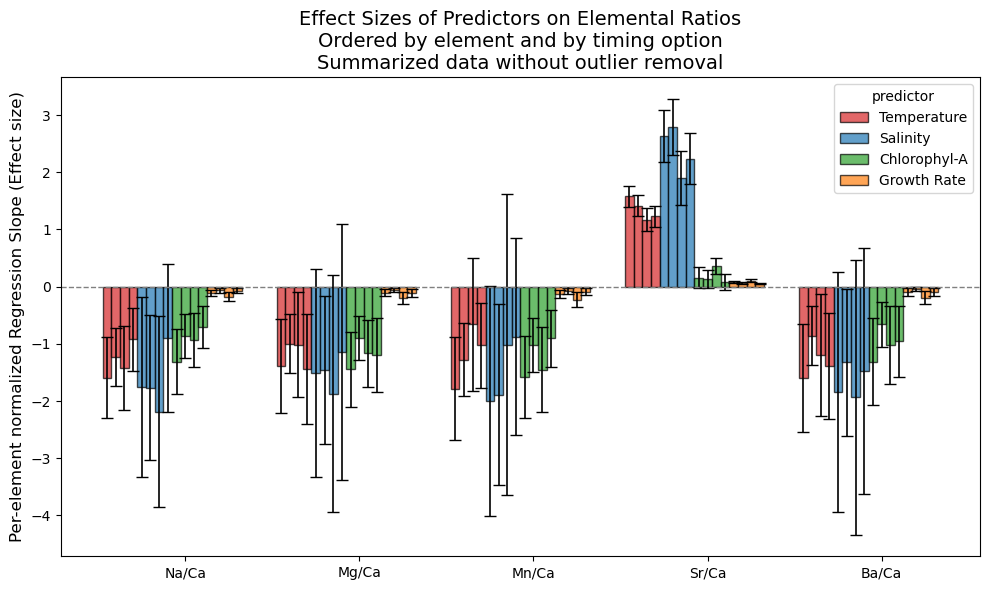

In [81]:
# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}
# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Plot with error bars
elements = peakID_stats_df['response'].unique()
predictors = peakID_stats_df['predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Normalize regression slopes and standard errors per element
element_slope_means = peakID_stats_df.groupby('response')['slope'].mean().abs()
peakID_stats_df = peakID_stats_df.merge(element_slope_means.rename('slope_mean'), on='response')
peakID_stats_df['slope_norm'] = peakID_stats_df['slope'] / peakID_stats_df['slope_mean']
peakID_stats_df['slope_std_err_norm'] = peakID_stats_df['slope_std_err'] / peakID_stats_df['slope_mean']

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(range(1, 5)): # loop over peakIDs
        # Subset data for this predictor & peakID (use parentheses for correct boolean logic)
        df_sub = peakID_stats_df[(peakID_stats_df['predictor'] == predictor) & (peakID_stats_df['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('response').reindex(elements)

        # get slopes and errors and prepare mask for valid entries (skip NaNs)
        slopes = df_sub['slope_norm'].values
        errs = df_sub['slope_std_err_norm'].values
        valid_mask = ~np.isnan(slopes)

        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                slopes[valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=errs[valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Per-element normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on Elemental Ratios\nOrdered by element and by timing option\nSummarized data without outlier removal', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

### Pairwise scatter plots with errors and by-specimen statistics and outlier removal

In [82]:
# Function to remove outliers based on the IQR method for both x and y (k = number of IQRs as benchmark)
def remove_outliers_iqr(df, x_col, y_col, k=1.5):
    """Remove outliers based on the IQR method for both x and y."""
    df = df[[x_col, y_col]].dropna()
    
    # X filtering
    Q1_x, Q3_x = df[x_col].quantile([0.25, 0.75])
    IQR_x = Q3_x - Q1_x
    x_mask = (df[x_col] >= Q1_x - k * IQR_x) & (df[x_col] <= Q3_x + k * IQR_x)

    # Y filtering
    Q1_y, Q3_y = df[y_col].quantile([0.25, 0.75])
    IQR_y = Q3_y - Q1_y
    y_mask = (df[y_col] >= Q1_y - k * IQR_y) & (df[y_col] <= Q3_y + k * IQR_y)

    # Combine masks
    return df[x_mask & y_mask]

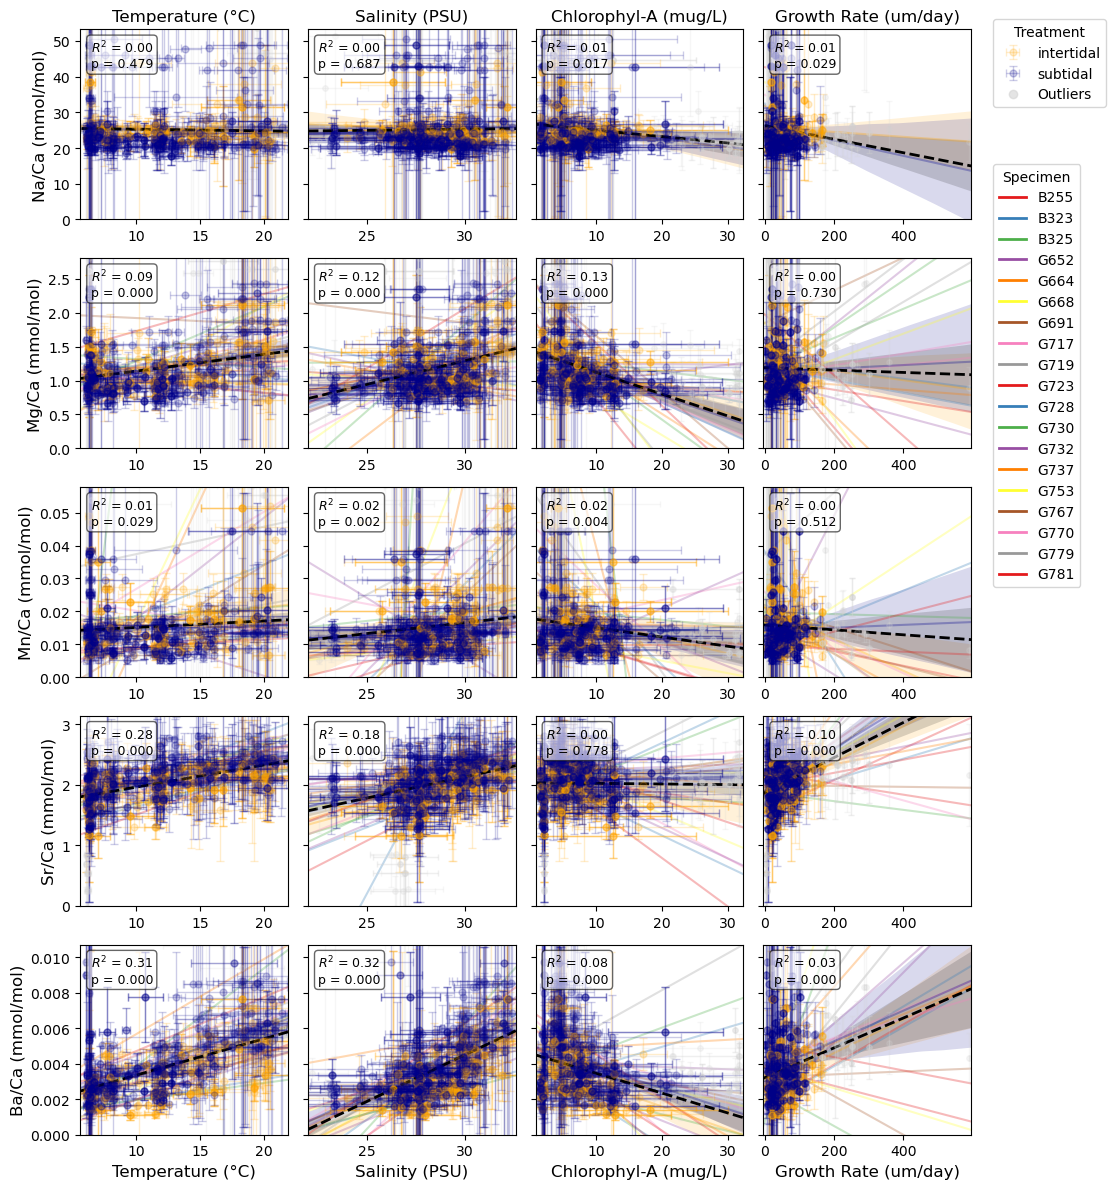

In [83]:
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_intervals['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Assign unique colors per treatment
treatments = data_intervals['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Store regression stats
global_stats_lin_outliers = {}      # global regression stats
specimen_stats_lin_outliers = {}    # regression stats per specimen
treatment_stats_lin_outliers = {}   # regression stats per treatment
peakID_stats_lin_outliers = {}      # regression stats per peakID (timing option)

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        for specimen in specimens:
            df_subset_raw = data_intervals[data_intervals['specimen'] == specimen] # All data for the current specimen
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response) # Clean data
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'treatment': df_subset_raw['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'treatment': df_subset_raw['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }
            
        # Secondly, plot per treatment
        for treatment in treatments:
            df_subset_raw = data_intervals[data_intervals['treatment'] == treatment] # Isolate data per treatment group
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response) # Clean data
            # Set color for the treatment
            color = treatment_colors[treatment]

            # Compute and store treatment-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_lin_outliers[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                treatment_stats_lin_outliers[(response, predictor, treatment)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }

            # Extract x, y, and error values for the current specimen
            # Separate raw and filtered data
            x_raw = df_subset_raw[predictor]
            y_raw = df_subset_raw[response]
            x_clean = df_subset[predictor]
            y_clean = df_subset[response]
            xerr = df_subset_raw[predictor_names[predictor]]
            yerr = df_subset_raw[response_names[response]]

            # Mask inliers
            inlier_mask = df_subset_raw.index.isin(df_subset.index)

            # Plot outliers in light gray
            ax.errorbar(x_raw[~inlier_mask],
                        y_raw[~inlier_mask],
                        xerr=xerr[~inlier_mask],
                        yerr=yerr[~inlier_mask],
                        fmt='o',
                        color='lightgray',
                        elinewidth=1,
                        alpha=0.2,
                        markersize=4,
                        capsize=2)

            # Plot inliers with color
            ax.errorbar(x_clean,
                        y_clean,
                        xerr=xerr[inlier_mask],
                        yerr=yerr[inlier_mask],
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.2,
                        markersize=5,
                        capsize=3,
                        label=treatment if (i == 0 and j == 0) else None)  # only label once for legend

            # Plot regression line per treatment
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=95,
                color=treatment_colors[treatment],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )
        
        # Now plot lines per peakID (timing option)
        for peakID in range(1, 5):
            df_subset_raw = data_intervals[data_intervals['peakID'] == peakID]
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response)
            # Compute and store peakID-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                peakID_stats_lin_outliers[(response, predictor, peakID)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_regs),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            else:
                peakID_stats_lin_outliers[(response, predictor, peakID)] = {
                    'r2': np.nan,
                    'p': np.nan,
                    'n': 0,
                    'slope': np.nan,
                    'slope_std_err': np.nan,
                    'intercept': np.nan,
                    'intercept_std_err': np.nan
                }
        
        # Prepare data for global regression line
        df_reg = remove_outliers_iqr(data_intervals, predictor, response)

        # Plot global regression line (all specimens)
        df_reg = df_reg[[predictor, response]].dropna()
        sns.regplot(
            x=predictor,
            y=response,
            data=df_reg,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_outliers[(response, predictor)] = {
            'r2': r2,
            'p': pval,
            'n': len(df_reg),
            'slope': model.params[predictor],
            'slope_std_err': model.bse[predictor],
            'intercept': model.params['const'],
            'intercept_std_err': model.bse['const']
        }

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            df_reg[response].max() + df_reg[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_intervals[predictor].min() - 0.1 * data_intervals[predictor].std(),
            data_intervals[predictor].max() + 0.1 * data_intervals[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add legend outside plot (only once)
handles, labels = axs[0, 0].get_legend_handles_labels()
# Add outlier legend handle (grey dot)
outlier_handle = Line2D([0], [0], marker='o', color='lightgray', label='Outliers',
                        linestyle='None', markersize=6, markerfacecolor='lightgray', alpha=0.6)
# Append to handles
handles.append(outlier_handle)
labels.append('Outliers')
fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(1.0, 0.9), title="Treatment")

# Specimen legend
specimen_legend_handles = [
    Line2D([0], [0], color=specimen_colors[spec], lw=2, label=spec)
    for spec in specimens
]

# Add specimen legend to the left of the figure
fig.legend(
    handles=specimen_legend_handles,
    loc='lower left',
    bbox_to_anchor=(1.0, 0.5),
    title='Specimen',
    fontsize=10
)

plt.tight_layout()
plt.show()

### Plot Spearman correlation matrix after outlier removal

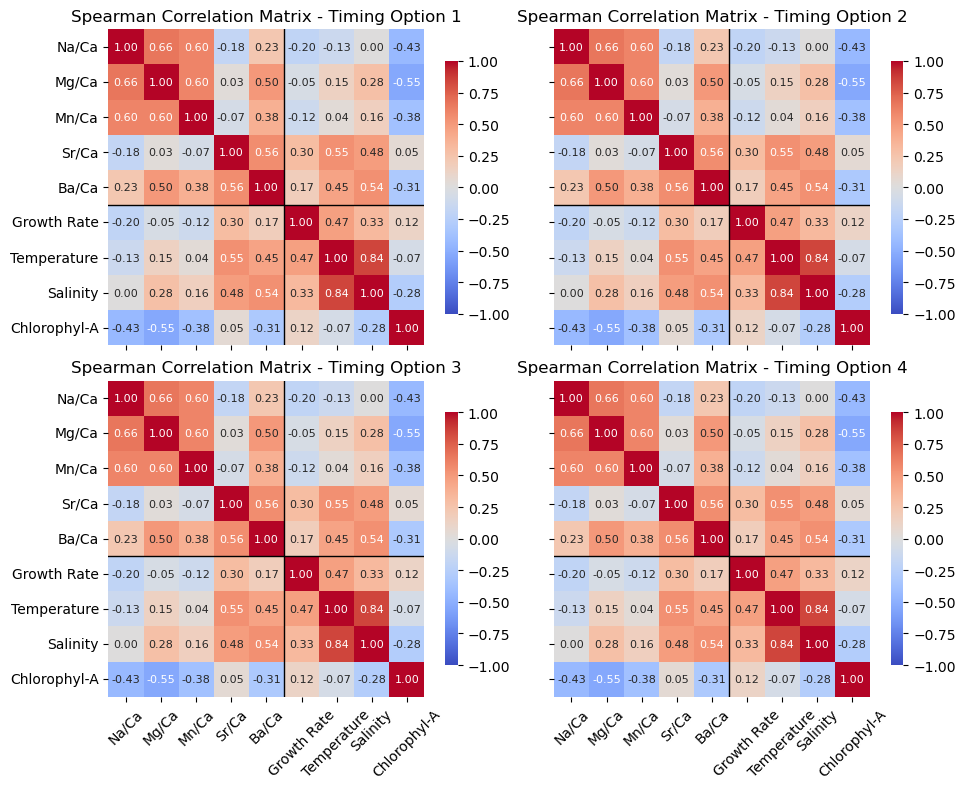

In [84]:
# Plot correlation matrix for data_intervals
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
    'Chl_mean'
]

# Plot correlation matrix for each timing option in 2x2 plotting grid
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axs.ravel()

for timing_option in range(1, 5):
    ax = axes[timing_option - 1]
    df_subset_raw = data_intervals[data_intervals['peakID'] == timing_option]
    df_subset = remove_outliers_iqr(df_subset_raw, predictor, response)
    data_subset_trim = data_subset[correlation_columns]
    
    # Compute correlation and apply renamed labels
    corr = data_subset_trim.corr(method = 'spearman')
    corr.rename(index=all_display_names, columns=all_display_names, inplace=True)
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, annot_kws={"size":8}, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'Spearman Correlation Matrix - Timing Option {timing_option}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

    # Add lines to separate predictors and responses
    ax.axhline(5, color='black', linewidth=1)
    ax.axvline(5, color='black', linewidth=1)

plt.tight_layout()
plt.show()

### Export regression results after outlier removal

In [85]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df_outliers = pd.DataFrame.from_dict(global_stats_lin_outliers, orient='index').reset_index()
global_stats_df_outliers.columns = ['response', 'predictor', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export regression results to CSV
global_stats_df_outliers.to_csv("Global_regression_stats_linear_outliers.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df_outliers = pd.DataFrame.from_dict(specimen_stats_lin_outliers, orient='index').reset_index()
specimen_stats_df_outliers.columns = ['response', 'predictor', 'specimen', 'treatment', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
specimen_stats_df_outliers.to_csv("Specimen_regression_stats_linear_outliers.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df_outliers = pd.DataFrame.from_dict(treatment_stats_lin_outliers, orient='index').reset_index()
treatment_stats_df_outliers.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
treatment_stats_df_outliers.to_csv("Treatment_regression_stats_linear_outliers.csv", index=False)

# Export peakID-specific regression stats to CSV
peakID_stats_df_outliers = pd.DataFrame.from_dict(peakID_stats_lin_outliers, orient='index').reset_index()
peakID_stats_df_outliers.columns = ['response', 'predictor', 'peakID', 'r2', 'p', 'n' , 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
peakID_stats_df_outliers.to_csv("PeakID_regression_stats_linear_outliers.csv", index=False)

### Plot effect size (slope) distribution over treatments

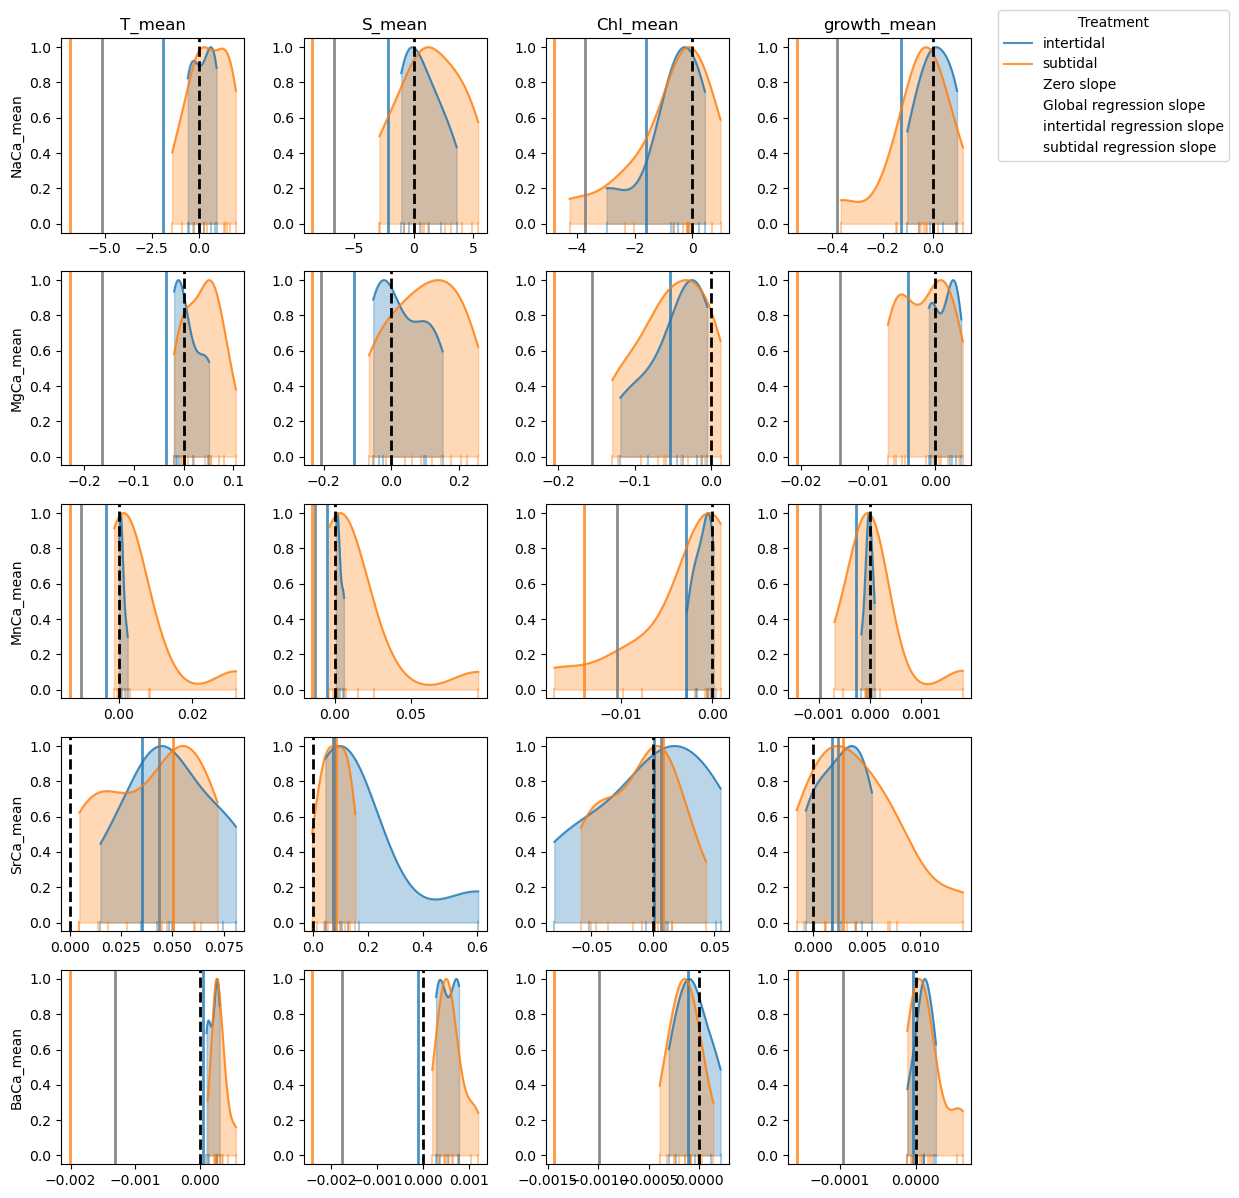

In [86]:
# Plot distribution of slopes of linear regression for each combination of response and predictor, colored by treatment

# Catch legend handles and labels
legend_handles = []
legend_labels = []

# Create dummy vertical lines for the per-treatment regression slopes here
dummy_regression_lines = {}

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12))

for i, resp in enumerate(responses):
    for j, pred in enumerate(predictors):
        ax = axs[i, j]
        # Loop over treatments
        for t_idx, treatment in enumerate(treatments):
            mask = ( # Filter for the specific response, predictor, and treatment
                (specimen_stats_df_outliers['predictor'] == pred) &
                (specimen_stats_df_outliers['response'] == resp) &
                (specimen_stats_df_outliers['treatment'] == treatment)
            )
            slopes = specimen_stats_df_outliers.loc[mask, 'slope'].tolist()
            # ax.hist(slopes, bins=20, alpha=0.5, label=treatment, density=True)
            if len(slopes) > 1:  # KDE needs more than one point
                # KDE calculation
                kde = stats.gaussian_kde(slopes)
                x_vals = np.linspace(min(slopes), max(slopes), 200)
                y_vals = kde(x_vals)
                y_vals /= y_vals.max()  # normalize to 0–1

                line, = ax.plot(x_vals, y_vals, color=sns.color_palette()[list(treatments).index(treatment)],
                        label=treatment if (i == 0 and j == 0) else None, alpha=0.8)
                ax.fill_between(x_vals, y_vals, alpha=0.3,
                                color=sns.color_palette()[list(treatments).index(treatment)])
                
                if i == 0 and j == 0:
                    legend_handles.append(line)
                    legend_labels.append(treatment)
            
            # Vertical bars for individual values
            for s in slopes:
                ax.axvline(s, color=sns.color_palette()[list(treatments).index(treatment)],
                            linestyle='-', alpha=0.4, ymin=0, ymax=0.05)  # short bar at bottom
            
            # Per-treatment regression slope line from treatment_stats_df
            treatment_mask = (
                (treatment_stats_df['predictor'] == pred) &
                (treatment_stats_df['response'] == resp) &
                (treatment_stats_df['treatment'] == treatment)
            )
            if not treatment_stats_df.loc[treatment_mask, 'slope'].empty:
                reg_slope = treatment_stats_df.loc[treatment_mask, 'slope'].iloc[0]
                ax.axvline(
                    reg_slope,
                    color=sns.color_palette()[list(treatments).index(treatment)],
                    linestyle='-',
                    linewidth=2,
                    alpha=0.8
                )

                # Create dummy regression line for legend once (on first subplot)
                if i == 0 and j == 0 and treatment not in dummy_regression_lines:
                    temp_ax = axs[0, 0]
                    dummy_line = temp_ax.axvline(
                        0,  # dummy x-position for legend
                        color=sns.color_palette()[t_idx],
                        linestyle='-',
                        linewidth=2,
                        alpha=0.8,
                        visible=False  # hide it on plot
                    )
                    dummy_regression_lines[treatment] = dummy_line

        # Grey dashed total regression slope from global_stats_df
        global_mask = (
            (global_stats_df['predictor'] == pred) &
            (global_stats_df['response'] == resp)
        )
        if not global_stats_df.loc[global_mask, 'slope'].empty:
            global_slope = global_stats_df.loc[global_mask, 'slope'].iloc[0]
            ax.axvline(
                global_slope,
                color='grey',
                linestyle='-',
                linewidth=2,
                alpha=0.9
            )

        # Add black dotted line at slope = 0
        ax.axvline(0, color='black', linestyle='--', linewidth=2)

        # Titles & labels
        if i == 0:
            ax.set_title(pred)
        if j == 0:
            ax.set_ylabel(resp)

# Use one axis to create dummy lines for legend handles
temp_ax = axs[0, 0]

# Create zero slope line handle
zero_line = temp_ax.axvline(0, color='black', linestyle='--', linewidth=1.2, visible=False)
# Create global slope line handle (example at x=0 just for legend, actual position doesn't matter)
global_line = temp_ax.axvline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.9, visible=False)

# Append these handles and labels
legend_handles.extend([zero_line, global_line])
legend_labels.extend(['Zero slope', 'Global regression slope'])

# Add dummy regression slope lines for each treatment to legend
for treatment, dummy_line in dummy_regression_lines.items():
    legend_handles.append(dummy_line)
    legend_labels.append(f'{treatment} regression slope')

# Create one global legend for the figure
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Treatment",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

plt.tight_layout()
plt.show()

### Plot effect sizes (slopes) as bar plots separated per peakID

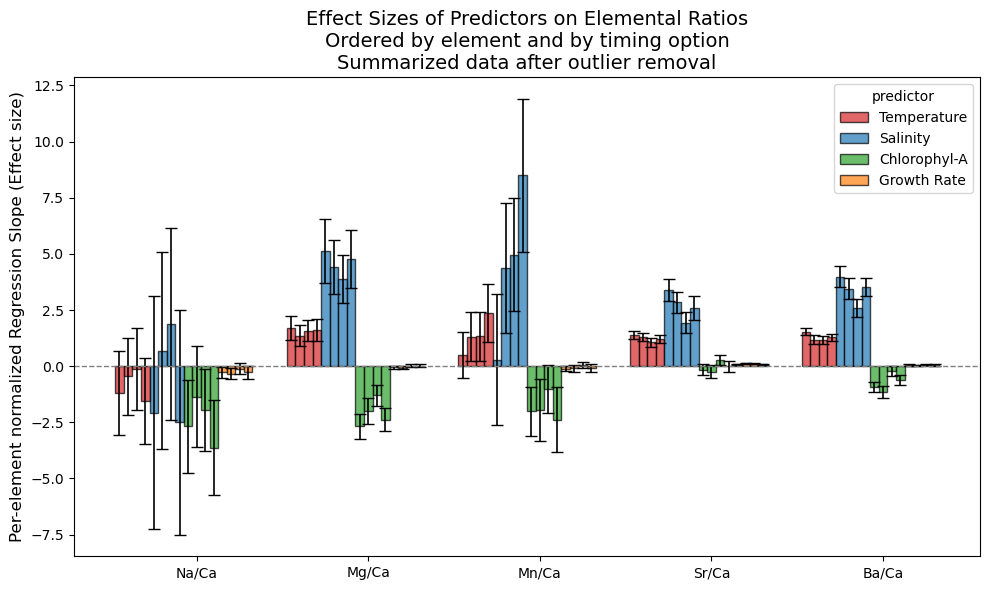

In [87]:
# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}
# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Plot with error bars
elements = peakID_stats_df_outliers['response'].unique()
predictors = peakID_stats_df_outliers['predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Normalize regression slopes and standard errors per element
element_slope_means = peakID_stats_df_outliers.groupby('response')['slope'].mean().abs()
peakID_stats_df_outliers = peakID_stats_df_outliers.merge(element_slope_means.rename('slope_mean'), on='response')
peakID_stats_df_outliers['slope_norm'] = peakID_stats_df_outliers['slope'] / peakID_stats_df_outliers['slope_mean']
peakID_stats_df_outliers['slope_std_err_norm'] = peakID_stats_df_outliers['slope_std_err'] / peakID_stats_df_outliers['slope_mean']

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(range(1, 5)): # loop over peakIDs
        # Subset data for this predictor & peakID (use parentheses for correct boolean logic)
        df_sub = peakID_stats_df_outliers[(peakID_stats_df_outliers['predictor'] == predictor) & (peakID_stats_df_outliers['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('response').reindex(elements)

        # get slopes and errors and prepare mask for valid entries (skip NaNs)
        slopes = df_sub['slope_norm'].values
        errs = df_sub['slope_std_err_norm'].values
        valid_mask = ~np.isnan(slopes)

        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                slopes[valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=errs[valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Per-element normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on Elemental Ratios\nOrdered by element and by timing option\nSummarized data after outlier removal', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

### Pairwise scatterplots with log-transformed response variables

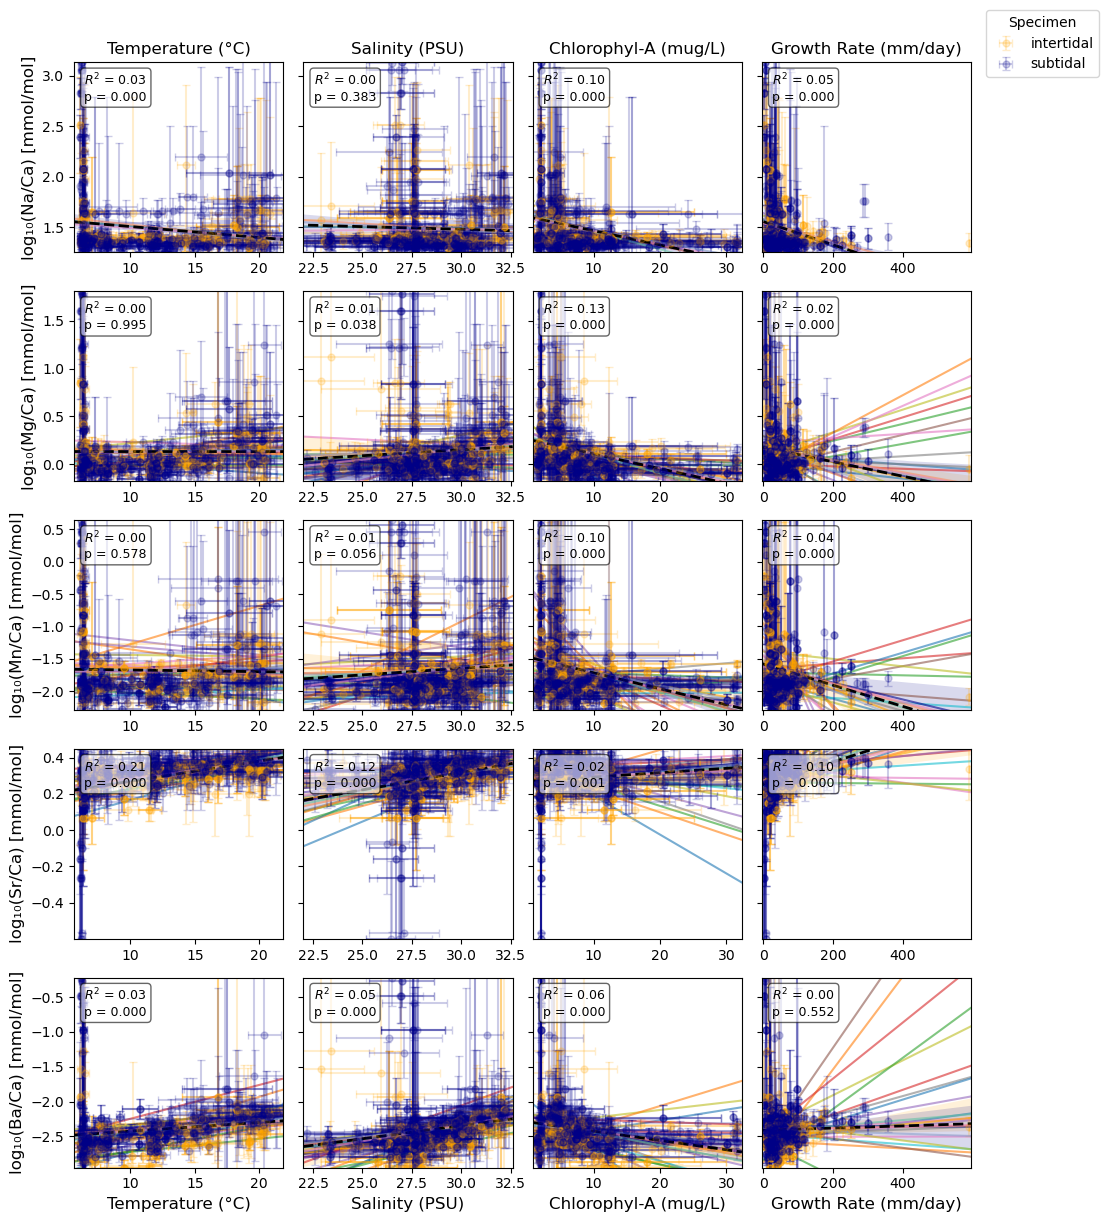

In [88]:
# Mappings and setup
predictor_errors = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'Chl_mean': 'Chl_sd',
    'growth_mean': 'growth_sd'
}

response_errors = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'Chl_mean': 'Chlorophyl-A (mug/L)',
    'growth_mean': 'Growth Rate (mm/day)'
}

response_display_names = {
    'NaCa_mean': 'log₁₀(Na/Ca) [mmol/mol]',
    'MgCa_mean': 'log₁₀(Mg/Ca) [mmol/mol]',
    'MnCa_mean': 'log₁₀(Mn/Ca) [mmol/mol]',
    'SrCa_mean': 'log₁₀(Sr/Ca) [mmol/mol]',
    'BaCa_mean': 'log₁₀(Ba/Ca) [mmol/mol]'
}

predictors = list(predictor_errors.keys())
responses = list(response_errors.keys())
specimens = data_intervals['specimen'].unique()
palette = sns.color_palette("tab10", len(specimens))
specimen_colors = dict(zip(specimens, palette))
treatments = data_intervals['treatment'].unique()
treatment_colors = {'subtidal': 'darkblue', 'intertidal': 'orange'}

# Create figure
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

# Regression stats storage
global_stats_log_all = {}
specimen_stats_log_all = {}
treatment_stats_log_all = {}
peakID_stats_log_all = {}

# Iterate through plots
for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]

        # Drop non-positive or missing response values for log-transform
        df_valid = data_intervals[[predictor, response, 'specimen', 'treatment', 'peakID',
                         predictor_errors[predictor], response_errors[response]]].copy()
        df_valid = df_valid[df_valid[response] > 0].dropna()

        # Log-transform the response
        df_valid[f'log_{response}'] = np.log10(df_valid[response])

        # Extract regression stats by specimen
        for specimen in specimens:
            df_subset_raw = df_valid[df_valid['specimen'] == specimen] # All valid data for the current specimen
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, f'log_{response}') # Clean data
            if len(df_subset) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_subset,
                    scatter=False, ax=ax,
                    ci=None, color=specimen_colors[specimen],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (specimen)
                Xs = sm.add_constant(df_subset[predictor])
                ys = df_subset[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_log_all[(response, predictor, specimen)] = {
                    'treatment': df_subset_raw['treatment'].iloc[0],  # Store treatment for the specimen
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_subset),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
        # Extract regressions stats by treatment
        for treatment in treatments:
            df_subset = df_valid[df_valid['treatment'] == treatment]
            if len(df_subset) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_subset,
                    scatter=False, ax=ax,
                    ci=95, color=treatment_colors[treatment],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (treatment)
                Xs = sm.add_constant(df_subset[predictor])
                ys = df_subset[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                treatment_stats_log_all[(response, predictor, treatment)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_subset),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
            # Plot error bars (original response, but log y)
            if not df_subset.empty:
                y_log = np.log10(df_subset[response])
                y_log_err = (df_subset[response_errors[response]] / df_subset[response]) / np.log(10)

                ax.errorbar(
                    df_subset[predictor], y_log,
                    xerr=df_subset[predictor_errors[predictor]],
                    yerr=y_log_err,
                    fmt='o', color=treatment_colors[treatment],
                    ecolor=treatment_colors[treatment],
                    alpha=0.2, capsize=3, markersize=5,
                    label=treatment if (i == 0 and j == 0) else None
                )
        # Extract regression stats by peakID
        for peakID in range(1, 5):
            df_subset = df_valid[df_valid['peakID'] == peakID]
            if len(df_subset) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_subset,
                    scatter=False, ax=ax,
                    ci=None, color=sns.color_palette("Set2")[peakID - 1],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (peakID)
                Xs = sm.add_constant(df_subset[predictor])
                ys = df_subset[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                peakID_stats_log_all[(response, predictor, peakID)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor],
                    'n': len(df_subset),
                    'slope': model_s.params[predictor],
                    'slope_std_err': model_s.bse[predictor],
                    'intercept': model_s.params['const'],
                    'intercept_std_err': model_s.bse['const']
                }
        # Global regression (log-transformed response)
        if len(df_valid) > 2:
            X = sm.add_constant(df_valid[predictor])
            y = df_valid[f'log_{response}']
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]

            global_stats_log_all[(response, predictor)] = {
                'r2': r2,
                'p': pval,
                'n': len(df_valid),
                'slope': model.params[predictor],
                'slope_std_err': model.bse[predictor],
                'intercept': model.params['const'],
                'intercept_std_err': model.bse['const']
            }

            # Plot global regression
            sns.regplot(
                x=predictor, y=f'log_{response}', data=df_valid,
                scatter=False, ax=ax,
                ci=None, color='black',
                line_kws={"lw": 2, "ls": "--"}, truncate=False
            )
        else:
            r2, pval = np.nan, np.nan

        # Annotate global regression stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
                     if not np.isnan(r2) and not np.isnan(pval)
                     else "Insufficient data")

        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

        # Axis labels
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        else:
            ax.set_title("")
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data rounded to next whole number
        ax.set_ylim(
            np.log10(data_intervals[response][np.isfinite(data_intervals[response]) & (data_intervals[response] > 0)].min()),
            np.log10(data_intervals[response][np.isfinite(data_intervals[response]) & (data_intervals[response] > 0)].max())
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_intervals[predictor].min() - 0.1 * data_intervals[predictor].std(),
            data_intervals[predictor].max() + 0.1 * data_intervals[predictor].std()
        )

        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Specimen", loc='upper right', bbox_to_anchor=(1.12, 1.02))

plt.tight_layout()
plt.show()

### Export regression results after log conversion

In [89]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df_log = pd.DataFrame.from_dict(global_stats_log_all, orient='index').reset_index()
global_stats_df_log.columns = ['response', 'predictor', 'r2', 'p', 'n', 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export regression results to CSV
global_stats_df_log.to_csv("Global_regression_stats_log_all.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df_log = pd.DataFrame.from_dict(specimen_stats_log_all, orient='index').reset_index()
specimen_stats_df_log.columns = ['response', 'predictor', 'specimen', 'treatment', 'r2', 'p', 'n', 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
specimen_stats_df_log.to_csv("Specimen_regression_stats_log_all.csv", index=False)

# Export treatment-specific regression stats to CSV
treatment_stats_df_log = pd.DataFrame.from_dict(treatment_stats_log_all, orient='index').reset_index()
treatment_stats_df_log.columns = ['response', 'predictor', 'treatment', 'r2', 'p', 'n', 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
treatment_stats_df_log.to_csv("treatment_regression_stats_log_all.csv", index=False)

# Export peakID-specific regression stats to CSV
peakID_stats_df_log = pd.DataFrame.from_dict(peakID_stats_log_all, orient='index').reset_index()
peakID_stats_df_log.columns = ['response', 'predictor', 'peakID', 'r2', 'p', 'n', 'slope', 'slope_std_err', 'intercept', 'intercept_std_err']
# Export to CSV
peakID_stats_df_log.to_csv("peakID_regression_stats_log_all.csv", index=False)

### Plot effect size (slope) distribution over specimens and treatments (log-lin regression)

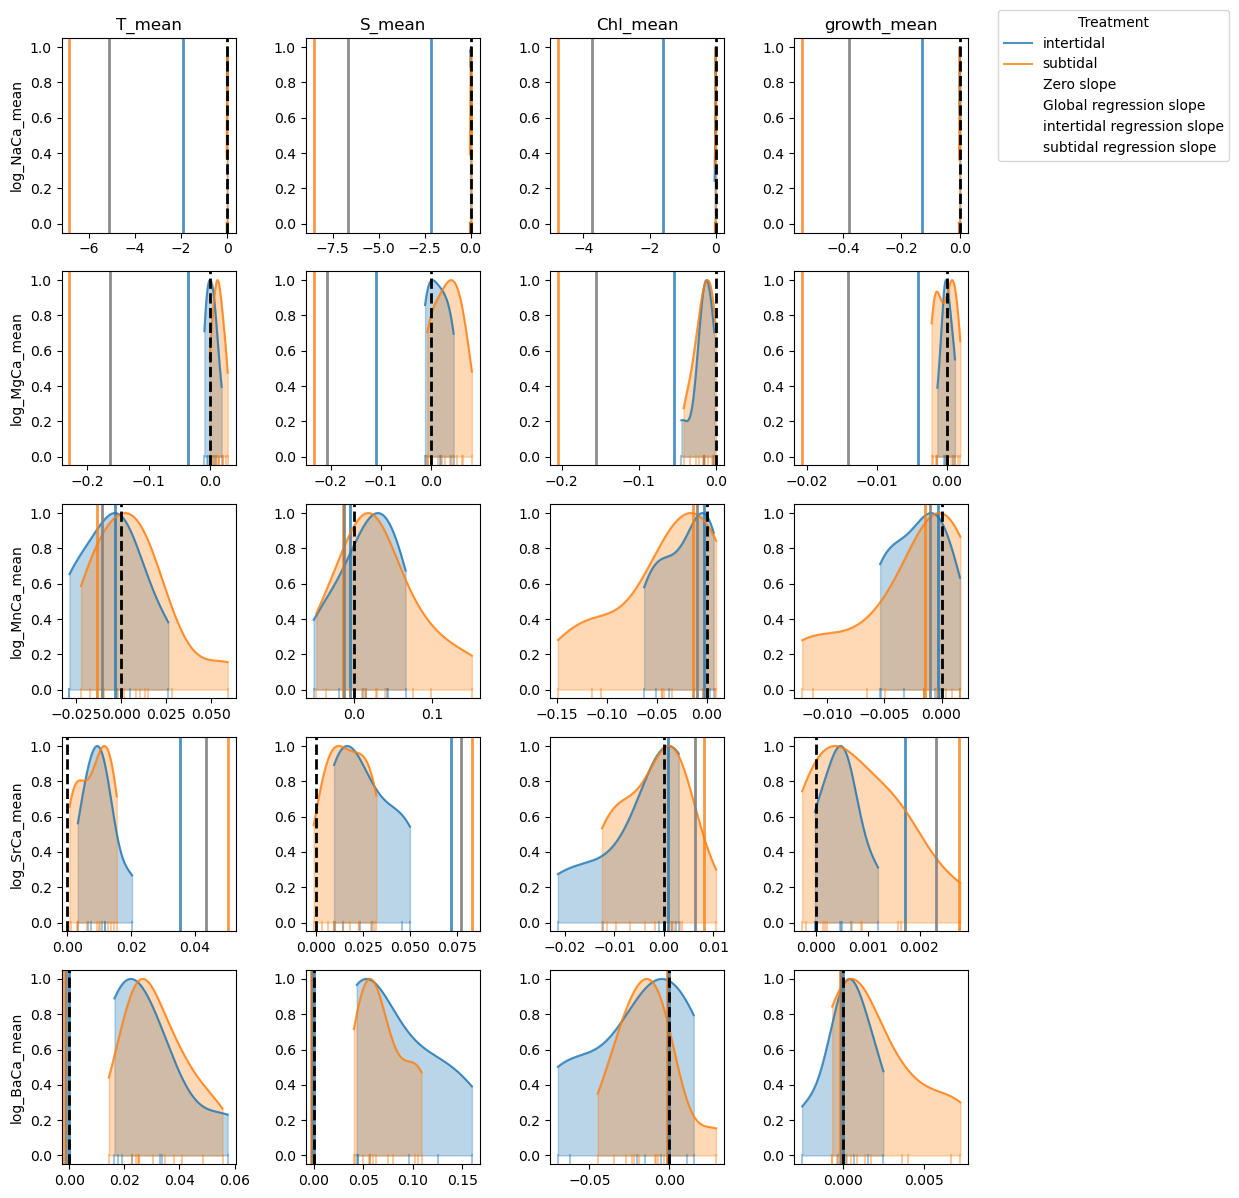

In [90]:
# Plot distribution of slopes of linear regression for each combination of response and predictor, colored by treatment

# Catch legend handles and labels
legend_handles = []
legend_labels = []

# Create dummy vertical lines for the per-treatment regression slopes here
dummy_regression_lines = {}

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12))

for i, resp in enumerate(responses):
    for j, pred in enumerate(predictors):
        ax = axs[i, j]
        # Loop over treatments
        for t_idx, treatment in enumerate(treatments):
            mask = ( # Filter for the specific response, predictor, and treatment
                (specimen_stats_df_log['predictor'] == pred) &
                (specimen_stats_df_log['response'] == resp) &
                (specimen_stats_df_log['treatment'] == treatment)
            )
            slopes = specimen_stats_df_log.loc[mask, 'slope'].tolist()
            # ax.hist(slopes, bins=20, alpha=0.5, label=treatment, density=True)
            if len(slopes) > 1:  # KDE needs more than one point
                # KDE calculation
                kde = stats.gaussian_kde(slopes)
                x_vals = np.linspace(min(slopes), max(slopes), 200)
                y_vals = kde(x_vals)
                y_vals /= y_vals.max()  # normalize to 0–1

                line, = ax.plot(x_vals, y_vals, color=sns.color_palette()[list(treatments).index(treatment)],
                        label=treatment if (i == 0 and j == 0) else None, alpha=0.8)
                ax.fill_between(x_vals, y_vals, alpha=0.3,
                                color=sns.color_palette()[list(treatments).index(treatment)])
                
                if i == 0 and j == 0:
                    legend_handles.append(line)
                    legend_labels.append(treatment)
            
            # Vertical bars for individual values
            for s in slopes:
                ax.axvline(s, color=sns.color_palette()[list(treatments).index(treatment)],
                            linestyle='-', alpha=0.4, ymin=0, ymax=0.05)  # short bar at bottom
            
            # Per-treatment regression slope line from treatment_stats_df
            treatment_mask = (
                (treatment_stats_df['predictor'] == pred) &
                (treatment_stats_df['response'] == resp) &
                (treatment_stats_df['treatment'] == treatment)
            )
            if not treatment_stats_df.loc[treatment_mask, 'slope'].empty:
                reg_slope = treatment_stats_df.loc[treatment_mask, 'slope'].iloc[0]
                ax.axvline(
                    reg_slope,
                    color=sns.color_palette()[list(treatments).index(treatment)],
                    linestyle='-',
                    linewidth=2,
                    alpha=0.8
                )

                # Create dummy regression line for legend once (on first subplot)
                if i == 0 and j == 0 and treatment not in dummy_regression_lines:
                    temp_ax = axs[0, 0]
                    dummy_line = temp_ax.axvline(
                        0,  # dummy x-position for legend
                        color=sns.color_palette()[t_idx],
                        linestyle='-',
                        linewidth=2,
                        alpha=0.8,
                        visible=False  # hide it on plot
                    )
                    dummy_regression_lines[treatment] = dummy_line

        # Grey dashed total regression slope from global_stats_df
        global_mask = (
            (global_stats_df['predictor'] == pred) &
            (global_stats_df['response'] == resp)
        )
        if not global_stats_df.loc[global_mask, 'slope'].empty:
            global_slope = global_stats_df.loc[global_mask, 'slope'].iloc[0]
            ax.axvline(
                global_slope,
                color='grey',
                linestyle='-',
                linewidth=2,
                alpha=0.9
            )

        # Add black dotted line at slope = 0
        ax.axvline(0, color='black', linestyle='--', linewidth=2)

        # Titles & labels
        if i == 0:
            ax.set_title(pred)
        if j == 0:
            ax.set_ylabel('log_' + resp)

# Use one axis to create dummy lines for legend handles
temp_ax = axs[0, 0]

# Create zero slope line handle
zero_line = temp_ax.axvline(0, color='black', linestyle='--', linewidth=1.2, visible=False)
# Create global slope line handle (example at x=0 just for legend, actual position doesn't matter)
global_line = temp_ax.axvline(0, color='grey', linestyle='--', linewidth=1.5, alpha=0.9, visible=False)

# Append these handles and labels
legend_handles.extend([zero_line, global_line])
legend_labels.extend(['Zero slope', 'Global regression slope'])

# Add dummy regression slope lines for each treatment to legend
for treatment, dummy_line in dummy_regression_lines.items():
    legend_handles.append(dummy_line)
    legend_labels.append(f'{treatment} regression slope')

# Create one global legend for the figure
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Treatment",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

plt.tight_layout()
plt.show()

### Plot effect sizes (slopes) as bar plots separated per peakID (log-transformed)

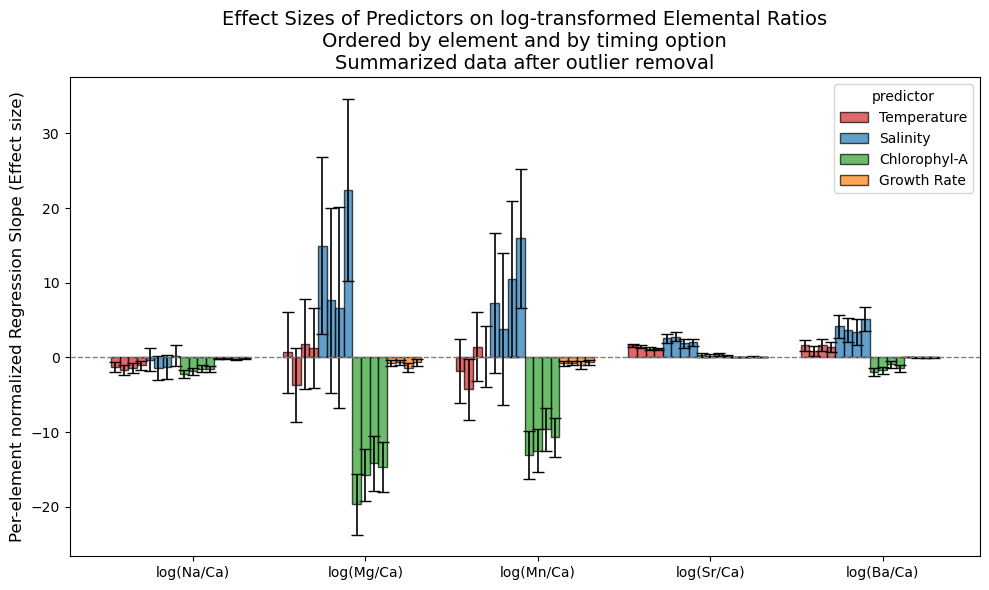

In [91]:
# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}
# Neat names for responses
response_map = {
    'NaCa_mean': 'log(Na/Ca)',
    'MgCa_mean': 'log(Mg/Ca)',
    'MnCa_mean': 'log(Mn/Ca)',
    'SrCa_mean': 'log(Sr/Ca)',
    'BaCa_mean': 'log(Ba/Ca)'
}

# Plot with error bars
elements = peakID_stats_df_log['response'].unique()
predictors = peakID_stats_df_log['predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Normalize regression slopes and standard errors per element
element_slope_means = peakID_stats_df_log.groupby('response')['slope'].mean().abs()
peakID_stats_df_log = peakID_stats_df_log.merge(element_slope_means.rename('slope_mean'), on='response')
peakID_stats_df_log['slope_norm'] = peakID_stats_df_log['slope'] / peakID_stats_df_log['slope_mean']
peakID_stats_df_log['slope_std_err_norm'] = peakID_stats_df_log['slope_std_err'] / peakID_stats_df_log['slope_mean']

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(range(1, 5)): # loop over peakIDs
        # Subset data for this predictor & peakID (use parentheses for correct boolean logic)
        df_sub = peakID_stats_df_log[(peakID_stats_df_log['predictor'] == predictor) & (peakID_stats_df_log['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('response').reindex(elements)

        # get slopes and errors and prepare mask for valid entries (skip NaNs)
        slopes = df_sub['slope_norm'].values
        errs = df_sub['slope_std_err_norm'].values
        valid_mask = ~np.isnan(slopes)

        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                slopes[valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=errs[valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Per-element normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on log-transformed Elemental Ratios\nOrdered by element and by timing option\nSummarized data after outlier removal', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

# Multivariate linear regression models

## Linear regressions of all elements based on summary data

In [93]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean', 'Chl_mean']

# Initialize an empty list
results_list_summarized = []

for peakID in range(0, 5):
    if(peakID == 0): # all data
        for element in outcome_vars:
            # Prepare the data for regression
            X = data_intervals[predictors].dropna()
            y = data_intervals[element]
            
            # Combine the predictors and outcome variable
            data_regression = pd.concat([X, y], axis=1).dropna()
            X = data_regression[predictors]
            y = data_regression[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model
            model = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized.append({
                'Element': element,
                'GR_slope': model.params[1],
                'GR_slope_se': model.bse[1],
                'T_slope': model.params[2],
                'T_slope_se': model.bse[2],
                'S_slope': model.params[3],
                'S_slope_se': model.bse[3],
                'Chl_slope': model.params[4],
                'Chl_slope_se': model.bse[4],
                'GR_slope_norm': model.params[1] / y.mean(),
                'GR_slope_norm_se': model.bse[1] / y.mean(),
                'T_slope_norm': model.params[2] / y.mean(),
                'T_slope_norm_se': model.bse[2] / y.mean(),
                'S_slope_norm': model.params[3] / y.mean(),
                'S_slope_norm_se': model.bse[3] / y.mean(),
                'Chl_slope_norm': model.params[4] / y.mean(),
                'Chl_slope_norm_se': model.bse[4] / y.mean(),
                'Intercept': model.params[0],
                'R_squared': model.rsquared,
                'P_value': model.pvalues[1],
                'Std_err': model.bse[1],
                'RSE': model.bse[1] / y.mean(),
                'peakID': 'All'
            })
    else: # data belonging to a specific peakID
        for element in outcome_vars:
            # Filter data for the specific peakID
            data_peak = data_intervals[data_intervals['peakID'] == peakID]
            
            # Prepare the data for regression
            X = data_peak[predictors].dropna()
            y = data_peak[element]
            
            # Combine the predictors and outcome variable
            data_regression = pd.concat([X, y], axis=1).dropna()
            X = data_regression[predictors]
            y = data_regression[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model
            model = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized.append({
                'Element': element,
                'GR_slope': model.params[1],
                'GR_slope_se': model.bse[1],
                'T_slope': model.params[2],
                'T_slope_se': model.bse[2],
                'S_slope': model.params[3],
                'S_slope_se': model.bse[3],
                'Chl_slope': model.params[4],
                'Chl_slope_se': model.bse[4],
                'GR_slope_norm': model.params[1] / y.mean(),
                'GR_slope_norm_se': model.bse[1] / y.mean(),
                'T_slope_norm': model.params[2] / y.mean(),
                'T_slope_norm_se': model.bse[2] / y.mean(),
                'S_slope_norm': model.params[3] / y.mean(),
                'S_slope_norm_se': model.bse[3] / y.mean(),
                'Chl_slope_norm': model.params[4] / y.mean(),
                'Chl_slope_norm_se': model.bse[4] / y.mean(),
                'Intercept': model.params[0],
                'R_squared': model.rsquared,
                'P_value': model.pvalues[1],
                'Std_err': model.bse[1],
                'RSE': model.bse[1] / y.mean(),
                'peakID': peakID
            })

# After the loop, create DataFrame
regression_results_summarized = pd.DataFrame(results_list_summarized)

# Display the regression results
print(regression_results_summarized)

# Export multiple regression summary
regression_results_summarized.to_csv("Multiple_regression_summary.csv", index=False)

      Element  GR_slope  GR_slope_se   T_slope  T_slope_se   S_slope  \
0   NaCa_mean -0.201146     0.108974 -7.919730    2.281609  6.030243   
1   MgCa_mean -0.008704     0.004752 -0.247864    0.099496  0.175666   
2   MnCa_mean -0.000651     0.000324 -0.015195    0.006782  0.010660   
3   SrCa_mean  0.000936     0.000257  0.045353    0.005374 -0.004912   
4   BaCa_mean -0.000052     0.000040 -0.001962    0.000832  0.001301   
5   NaCa_mean -0.185360     0.241439 -9.914575    5.029061  6.867331   
6   MgCa_mean -0.007378     0.009440 -0.281377    0.196623  0.170736   
7   MnCa_mean -0.000531     0.000656 -0.022645    0.013668  0.014454   
8   SrCa_mean  0.000919     0.000510  0.051057    0.010614 -0.000842   
9   BaCa_mean -0.000039     0.000084 -0.002569    0.001761  0.001515   
10  NaCa_mean -0.132233     0.151085 -8.534600    4.089514  6.945966   
11  MgCa_mean -0.004286     0.005197 -0.222802    0.140683  0.136306   
12  MnCa_mean -0.000362     0.000405 -0.017612    0.010954  0.01

C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\2975366625.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope': model.params[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\2975366625.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope_se': model.bse[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\2975366625.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'T_slope': model.params[2],
C:\Users

### Plot effect sizes of predictors

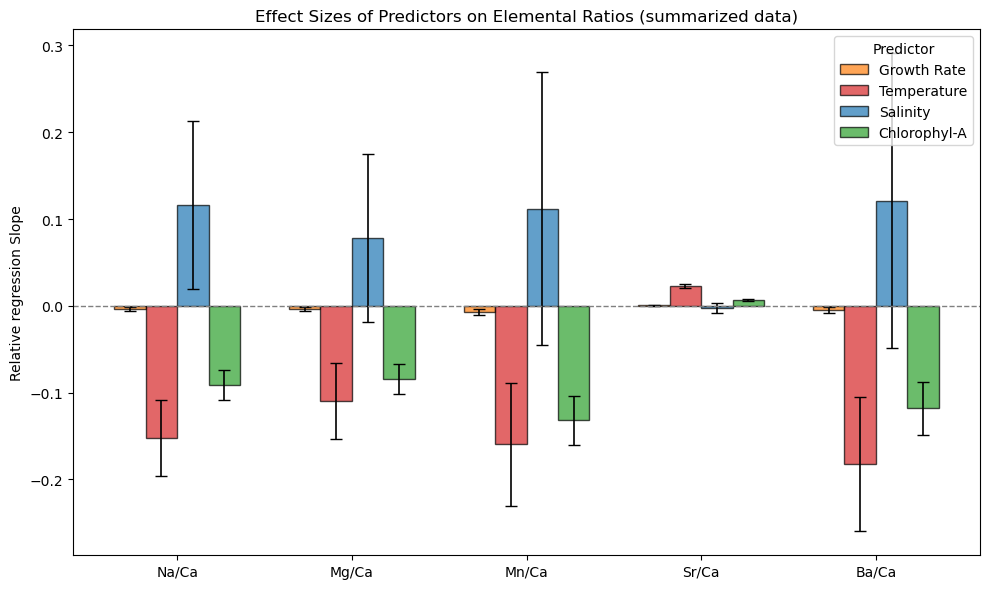

In [94]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized = regression_results_summarized[
    regression_results_summarized['peakID'] == 'All'
].melt(
    id_vars=['Element', 'R_squared', 'P_value'],
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_se = regression_results_summarized[
    regression_results_summarized['peakID'] == 'All'
].melt(
    id_vars='Element',
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='Predictor',
    value_name='SE'
)

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_summarized['Predictor'] = effect_sizes_summarized['Predictor'].map(predictor_map)
effect_sizes_summarized_se['Predictor'] = effect_sizes_summarized_se['Predictor'].map(predictor_map)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data = pd.merge(effect_sizes_summarized, effect_sizes_summarized_se, on=['Element', 'Predictor'])

# Plot with error bars
elements = plot_data['Element'].unique()
predictors = plot_data['Predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width = 0.18

# Define colors for each predictor
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    # Subset data for this predictor
    df_sub = plot_data[plot_data['Predictor'] == predictor]

    # Align bar positions: offset each predictor
    positions = x + i * width
    
    # Use the color for this predictor
    color = predictor_colors.get(predictor, 'gray')  # fallback to gray if not found

    # Draw bars
    ax.bar(
        positions,
        df_sub['EffectSize'],
        width=width,
        label=predictor,
        yerr=df_sub['SE'],
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=color,
        alpha=0.7,
        edgecolor='black'
    )

    # # Highlight significant effect sizes
    # for j, p in enumerate(df_sub['P_value']):
    #     if(p < 0.05):
    #         ax.annotate(
    #             text = "*",
    #             xy = (positions[j], df_sub['EffectSize'][j]),
    #             ha = 'center',
    #             va = 'center'
    #         )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Relative regression Slope')
ax.set_title('Effect Sizes of Predictors on Elemental Ratios (summarized data)')
ax.legend(title='Predictor')

plt.tight_layout()
plt.show()

### Plot multiple regression effect sizes per peakID

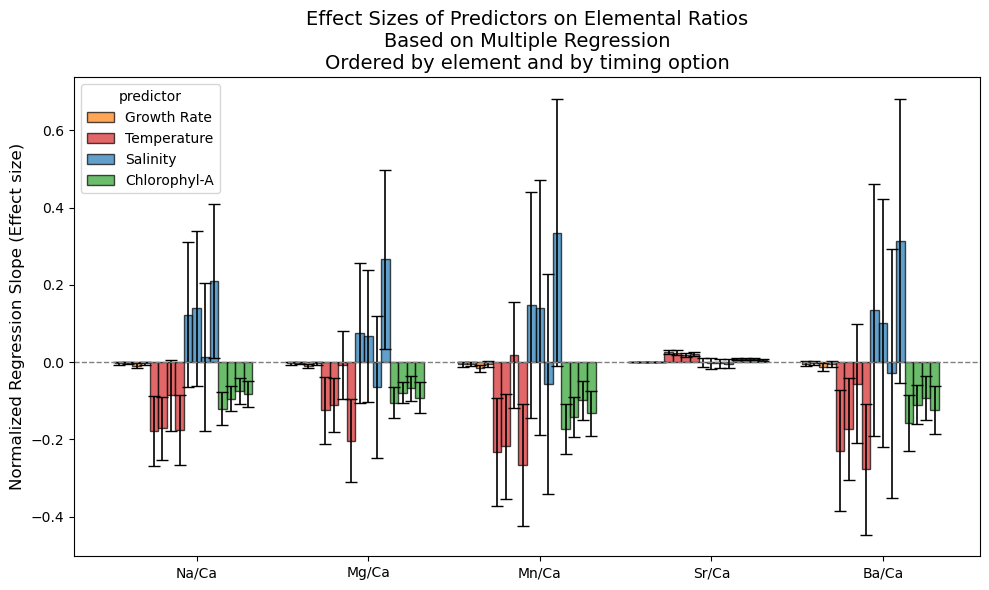

In [95]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized = regression_results_summarized[
    regression_results_summarized['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_se = regression_results_summarized[
    regression_results_summarized['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='predictor',
    value_name='SE'
)

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_summarized['predictor'] = effect_sizes_summarized['predictor'].map(predictor_map)
effect_sizes_summarized['peakID'] = effect_sizes_summarized['peakID'].astype(int)
effect_sizes_summarized_se['predictor'] = effect_sizes_summarized_se['predictor'].map(predictor_map)
effect_sizes_summarized_se['peakID'] = effect_sizes_summarized_se['peakID'].astype(int)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data = pd.merge(effect_sizes_summarized, effect_sizes_summarized_se, on=['Element', 'predictor', 'peakID'])

# Plot with error bars
elements = plot_data['Element'].unique()
predictors = plot_data['predictor'].unique()
peakIDs = plot_data['peakID'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(peakIDs): # loop over peakIDs
        # Subset data for this predictor
        df_sub = plot_data[(plot_data['predictor'] == predictor) & (plot_data['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('Element').reindex(elements)

        valid_mask = ~np.isnan(df_sub['EffectSize'].values)
        
        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                df_sub['EffectSize'][valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=df_sub['SE'][valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on Elemental Ratios\nBased on Multiple Regression\nOrdered by element and by timing option', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

## Repeat MLR but exclude 7 samples with bad agreement in peakIDs

In [96]:
# Set up a multiple regression model using statsmodels, but for a selection of the specimens
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean', 'Chl_mean']

# Select specimens to exclude (excluding the 7 specimens with least reproducible peakIDs)
bad_specimens = [
    "G781",
    "G732",
    "B255",
    "G753",
    "G770",
    "G779",
    "G652"
]
data_intervals_select = data_intervals[~data_intervals["specimen"].isin(bad_specimens)]

# Initialize an empty list
results_list_summarized_select = []

for peakID in range(0, 5):
    if(peakID == 0): # all data
        for element in outcome_vars:
            # Prepare the data for regression
            X = data_intervals_select[predictors].dropna()
            y = data_intervals_select[element]
            
            # Combine the predictors and outcome variable
            data_regression_select = pd.concat([X, y], axis=1).dropna()
            X = data_regression_select[predictors]
            y = data_regression_select[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model_select
            model_select = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized_select.append({
                'Element': element,
                'GR_slope': model_select.params[1],
                'GR_slope_se': model_select.bse[1],
                'T_slope': model_select.params[2],
                'T_slope_se': model_select.bse[2],
                'S_slope': model_select.params[3],
                'S_slope_se': model_select.bse[3],
                'Chl_slope': model_select.params[4],
                'Chl_slope_se': model_select.bse[4],
                'GR_slope_norm': model_select.params[1] / y.mean(),
                'GR_slope_norm_se': model_select.bse[1] / y.mean(),
                'T_slope_norm': model_select.params[2] / y.mean(),
                'T_slope_norm_se': model_select.bse[2] / y.mean(),
                'S_slope_norm': model_select.params[3] / y.mean(),
                'S_slope_norm_se': model_select.bse[3] / y.mean(),
                'Chl_slope_norm': model_select.params[4] / y.mean(),
                'Chl_slope_norm_se': model_select.bse[4] / y.mean(),
                'Intercept': model_select.params[0],
                'R_squared': model_select.rsquared,
                'P_value': model_select.pvalues[1],
                'Std_err': model_select.bse[1],
                'RSE': model_select.bse[1] / y.mean(),
                'peakID': 'All'
            })
    else: # data belonging to a specific peakID
        for element in outcome_vars:
            # Filter data for the specific peakID
            data_peak_select = data_intervals_select[data_intervals_select['peakID'] == peakID]
            
            # Prepare the data for regression
            X = data_peak_select[predictors].dropna()
            y = data_peak_select[element]
            
            # Combine the predictors and outcome variable
            data_regression_select = pd.concat([X, y], axis=1).dropna()
            X = data_regression_select[predictors]
            y = data_regression_select[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model_select
            model_select = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized_select.append({
                'Element': element,
                'GR_slope': model_select.params[1],
                'GR_slope_se': model_select.bse[1],
                'T_slope': model_select.params[2],
                'T_slope_se': model_select.bse[2],
                'S_slope': model_select.params[3],
                'S_slope_se': model_select.bse[3],
                'Chl_slope': model_select.params[4],
                'Chl_slope_se': model_select.bse[4],
                'GR_slope_norm': model_select.params[1] / y.mean(),
                'GR_slope_norm_se': model_select.bse[1] / y.mean(),
                'T_slope_norm': model_select.params[2] / y.mean(),
                'T_slope_norm_se': model_select.bse[2] / y.mean(),
                'S_slope_norm': model_select.params[3] / y.mean(),
                'S_slope_norm_se': model_select.bse[3] / y.mean(),
                'Chl_slope_norm': model_select.params[4] / y.mean(),
                'Chl_slope_norm_se': model_select.bse[4] / y.mean(),
                'Intercept': model_select.params[0],
                'R_squared': model_select.rsquared,
                'P_value': model_select.pvalues[1],
                'Std_err': model_select.bse[1],
                'RSE': model_select.bse[1] / y.mean(),
                'peakID': peakID
            })

# After the loop, create DataFrame
regression_results_summarized_select = pd.DataFrame(results_list_summarized_select)

# Display the regression results
print(regression_results_summarized_select)

# Export multiple regression summary
regression_results_summarized_select.to_csv("Multiple_regression_summary_select.csv", index=False)

C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope': model_select.params[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope_se': model_select.bse[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'T_slope': model_selec

      Element  GR_slope  GR_slope_se    T_slope  T_slope_se   S_slope  \
0   NaCa_mean -0.395224     0.216747  -7.553635    3.254587  3.889917   
1   MgCa_mean -0.014095     0.008054  -0.140820    0.120934 -0.050161   
2   MnCa_mean -0.001229     0.000645  -0.011866    0.009689  0.002942   
3   SrCa_mean  0.001265     0.000417   0.042422    0.006260 -0.002090   
4   BaCa_mean -0.000099     0.000073  -0.001480    0.001095  0.000324   
5   NaCa_mean -0.280745     0.427412 -10.580055    7.292040  6.794004   
6   MgCa_mean -0.010233     0.015148  -0.245836    0.258442  0.096067   
7   MnCa_mean -0.000771     0.001151  -0.023272    0.019642  0.014071   
8   SrCa_mean  0.000653     0.000761   0.044292    0.012979  0.003894   
9   BaCa_mean -0.000062     0.000138  -0.002403    0.002368  0.001390   
10  NaCa_mean -0.384648     0.384505  -6.584376    5.290346  5.451288   
11  MgCa_mean -0.007556     0.008065  -0.122783    0.110965  0.007515   
12  MnCa_mean -0.000957     0.001014  -0.012453    

C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope': model_select.params[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:91: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope_se': model_select.bse[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\4270901798.py:92: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'T_slope': model_selec

### Plot effect sizes of predictors (exclude badly reproduced specimens)

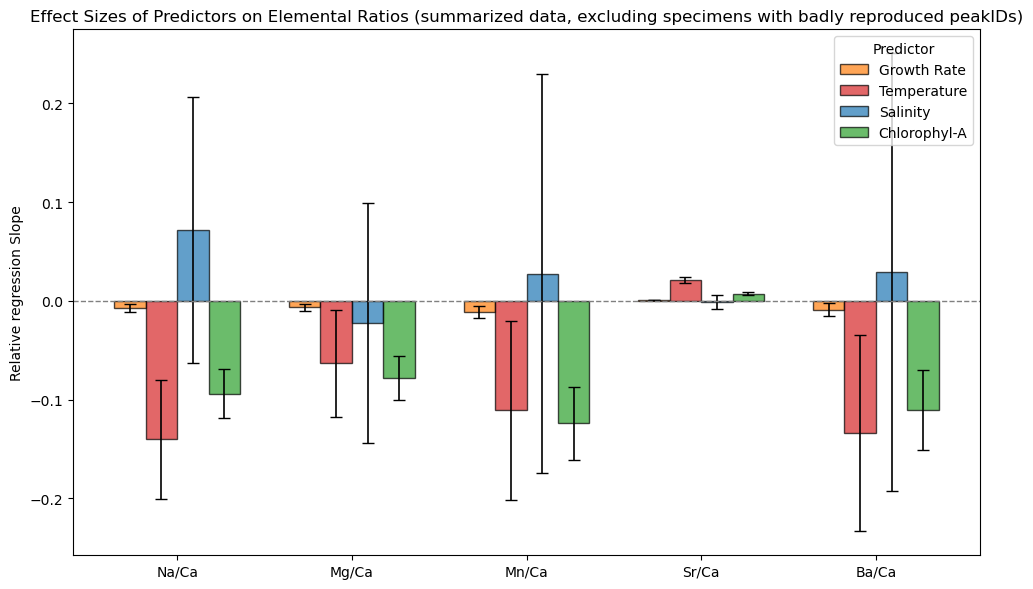

In [97]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized_select = regression_results_summarized_select[
    regression_results_summarized_select['peakID'] == 'All'
].melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_select_se = regression_results_summarized_select[
    regression_results_summarized_select['peakID'] == 'All'
].melt(
    id_vars='Element',
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='Predictor',
    value_name='SE'
)

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_summarized_select['Predictor'] = effect_sizes_summarized_select['Predictor'].map(predictor_map)
effect_sizes_summarized_select_se['Predictor'] = effect_sizes_summarized_select_se['Predictor'].map(predictor_map)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data_select = pd.merge(effect_sizes_summarized_select, effect_sizes_summarized_select_se, on=['Element', 'Predictor'])

# Plot with error bars
elements = plot_data_select['Element'].unique()
predictors = plot_data_select['Predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width = 0.18

# Define colors for each predictor
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    # Subset data for this predictor
    df_sub = plot_data_select[plot_data_select['Predictor'] == predictor]

    # Align bar positions: offset each predictor
    positions = x + i * width
    
    # Use the color for this predictor
    color = predictor_colors.get(predictor, 'gray')  # fallback to gray if not found

    # Draw bars
    ax.bar(
        positions,
        df_sub['EffectSize'],
        width=width,
        label=predictor,
        yerr=df_sub['SE'],
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=color,
        alpha=0.7,
        edgecolor='black'
    )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Relative regression Slope')
ax.set_title('Effect Sizes of Predictors on Elemental Ratios (summarized data, excluding specimens with badly reproduced peakIDs)')
ax.legend(title='Predictor')

plt.tight_layout()
plt.show()

### Plot multiple regression effect sizes per peakID (exclude badly reproduced specimens)

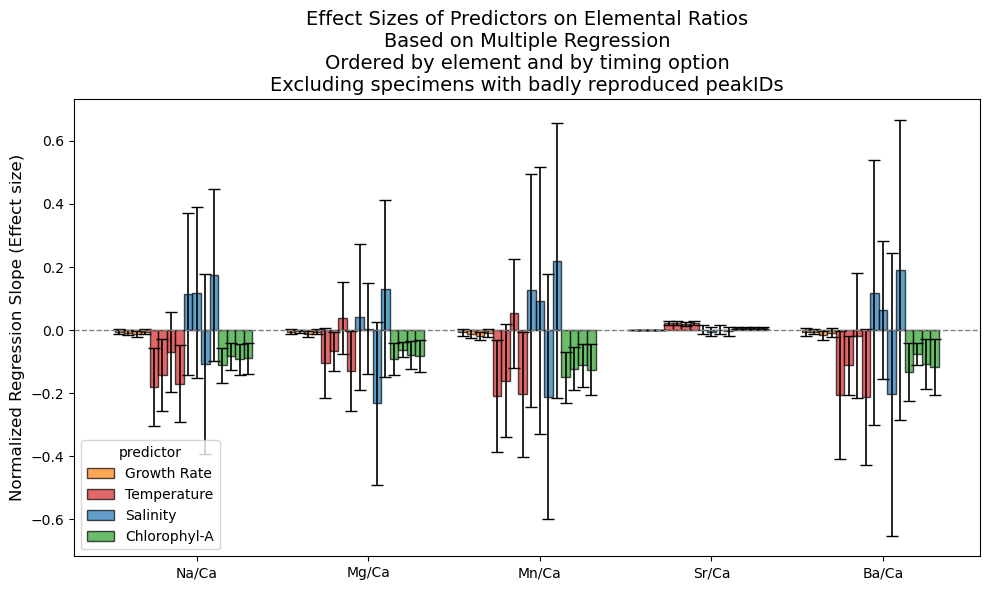

In [98]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized_select = regression_results_summarized_select[
    regression_results_summarized_select['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm', 'Chl_slope_norm'],
    var_name='predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_select_se = regression_results_summarized_select[
    regression_results_summarized_select['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope_norm_se', 'T_slope_norm_se', 'S_slope_norm_se', 'Chl_slope_norm_se'],
    var_name='predictor',
    value_name='SE'
)

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity',
    'Chl_slope_norm': 'Chlorophyl-A',
    'GR_slope_norm_se': 'Growth Rate',
    'T_slope_norm_se': 'Temperature',
    'S_slope_norm_se': 'Salinity',
    'Chl_slope_norm_se': 'Chlorophyl-A'
}
effect_sizes_summarized_select['predictor'] = effect_sizes_summarized_select['predictor'].map(predictor_map)
effect_sizes_summarized_select['peakID'] = effect_sizes_summarized_select['peakID'].astype(int)
effect_sizes_summarized_select_se['predictor'] = effect_sizes_summarized_select_se['predictor'].map(predictor_map)
effect_sizes_summarized_select_se['peakID'] = effect_sizes_summarized_select_se['peakID'].astype(int)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data_select = pd.merge(effect_sizes_summarized_select, effect_sizes_summarized_select_se, on=['Element', 'predictor', 'peakID'])

# Plot with error bars
elements = plot_data_select['Element'].unique()
predictors = plot_data_select['predictor'].unique()
peakIDs = plot_data_select['peakID'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(peakIDs): # loop over peakIDs
        # Subset data for this predictor
        df_sub = plot_data_select[(plot_data_select['predictor'] == predictor) & (plot_data_select['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('Element').reindex(elements)

        valid_mask = ~np.isnan(df_sub['EffectSize'].values)
        
        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                df_sub['EffectSize'][valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=df_sub['SE'][valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on Elemental Ratios\nBased on Multiple Regression\nOrdered by element and by timing option\nExcluding specimens with badly reproduced peakIDs', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

## Linear regressions of all elements based on summary data normalized to Z-scores

In [99]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean', 'Chl_mean']

# Normalize all variables to z-scores before regression
cols = [
    'NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean',
    'growth_mean', 'T_mean', 'S_mean', 'Chl_mean'
]
data_intervals_z = data_intervals.copy()
data_intervals_z[cols] = (data_intervals_z[cols] - data_intervals_z[cols].mean()) / data_intervals_z[cols].std()

# Initialize an empty list
results_list_summarized_z = []

for peakID in range(0, 5):
    if(peakID == 0): # all data
        for element in outcome_vars:
            # Prepare the data for regression
            X = data_intervals_z[predictors].dropna()
            y = data_intervals_z[element]
            
            # Combine the predictors and outcome variable
            data_regression = pd.concat([X, y], axis=1).dropna()
            X = data_regression[predictors]
            y = data_regression[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model
            model = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized_z.append({
                'Element': element,
                'GR_slope': model.params[1],
                'GR_slope_se': model.bse[1],
                'T_slope': model.params[2],
                'T_slope_se': model.bse[2],
                'S_slope': model.params[3],
                'S_slope_se': model.bse[3],
                'Chl_slope': model.params[4],
                'Chl_slope_se': model.bse[4],
                'Intercept': model.params[0],
                'R_squared': model.rsquared,
                'P_value': model.pvalues[1],
                'Std_err': model.bse[1],
                'RSE': model.bse[1] / y.mean(),
                'peakID': 'All'
            })
    else: # data belonging to a specific peakID
        for element in outcome_vars:
            # Filter data for the specific peakID
            data_peak = data_intervals_z[data_intervals_z['peakID'] == peakID]
            
            # Prepare the data for regression
            X = data_peak[predictors].dropna()
            y = data_peak[element]
            
            # Combine the predictors and outcome variable
            data_regression = pd.concat([X, y], axis=1).dropna()
            X = data_regression[predictors]
            y = data_regression[element]

            # Add a constant to the predictors
            X = sm.add_constant(X)
            
            # Fit the regression model
            model = sm.OLS(y, X).fit()

            # Inside your loop
            results_list_summarized_z.append({
                'Element': element,
                'GR_slope': model.params[1],
                'GR_slope_se': model.bse[1],
                'T_slope': model.params[2],
                'T_slope_se': model.bse[2],
                'S_slope': model.params[3],
                'S_slope_se': model.bse[3],
                'Chl_slope': model.params[4],
                'Chl_slope_se': model.bse[4],
                'Intercept': model.params[0],
                'R_squared': model.rsquared,
                'P_value': model.pvalues[1],
                'Std_err': model.bse[1],
                'RSE': model.bse[1] / y.mean(),
                'peakID': peakID
            })

# After the loop, create DataFrame
regression_results_summarized_z = pd.DataFrame(results_list_summarized_z)

# Display the regression results
print(regression_results_summarized_z)

# Export multiple regression summary
regression_results_summarized_z.to_csv("Multiple_regression_summary_zscores.csv", index=False)

      Element  GR_slope  GR_slope_se   T_slope  T_slope_se   S_slope  \
0   NaCa_mean -0.084277     0.045658 -0.269547    0.077654  0.088815   
1   MgCa_mean -0.084685     0.046233 -0.195890    0.078633  0.060078   
2   MnCa_mean -0.093098     0.046324 -0.176521    0.078787  0.053590   
3   SrCa_mean  0.140269     0.038460  0.552003    0.065412 -0.025869   
4   BaCa_mean -0.060991     0.046731 -0.187657    0.079527  0.053851   
5   NaCa_mean -0.077663     0.101159 -0.337441    0.171163  0.101144   
6   MgCa_mean -0.071784     0.091838 -0.222375    0.155393  0.058392   
7   MnCa_mean -0.076003     0.093840 -0.263070    0.158780  0.072662   
8   SrCa_mean  0.137737     0.076346  0.621428    0.129179 -0.004437   
9   BaCa_mean -0.045538     0.099248 -0.245711    0.168438  0.062704   
10  NaCa_mean -0.055403     0.063302 -0.290474    0.139186  0.102302   
11  MgCa_mean -0.041699     0.050566 -0.176083    0.111183  0.046617   
12  MnCa_mean -0.051720     0.057875 -0.204592    0.127255  0.05

C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\584408791.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope': model.params[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\584408791.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'GR_slope_se': model.bse[1],
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\584408791.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'T_slope': model.params[2],
C:\Users\nw

### Plot effect sizes of predictors (data prepared as z-scores)

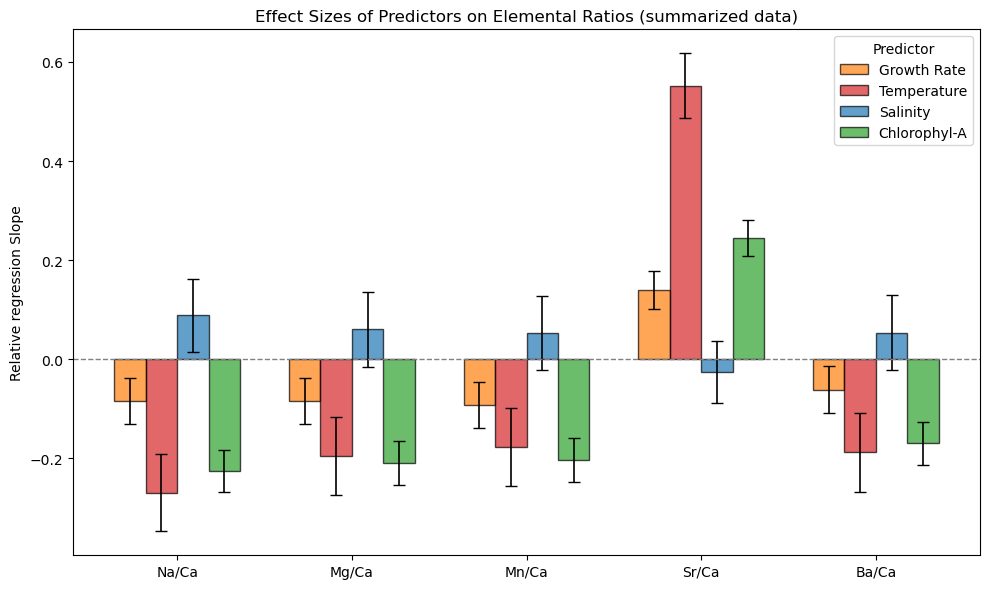

In [100]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized_z = regression_results_summarized_z[
    regression_results_summarized_z['peakID'] == 'All'
].melt(
    id_vars=['Element', 'R_squared', 'P_value'],
    value_vars=['GR_slope', 'T_slope', 'S_slope', 'Chl_slope'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_z_se = regression_results_summarized_z[
    regression_results_summarized_z['peakID'] == 'All'
].melt(
    id_vars='Element',
    value_vars=['GR_slope_se', 'T_slope_se', 'S_slope_se', 'Chl_slope_se'],
    var_name='Predictor',
    value_name='SE'
)

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope': 'Growth Rate',
    'T_slope': 'Temperature',
    'S_slope': 'Salinity',
    'Chl_slope': 'Chlorophyl-A',
    'GR_slope_se': 'Growth Rate',
    'T_slope_se': 'Temperature',
    'S_slope_se': 'Salinity',
    'Chl_slope_se': 'Chlorophyl-A'
}
effect_sizes_summarized_z['Predictor'] = effect_sizes_summarized_z['Predictor'].map(predictor_map)
effect_sizes_summarized_z_se['Predictor'] = effect_sizes_summarized_z_se['Predictor'].map(predictor_map)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data_z = pd.merge(effect_sizes_summarized_z, effect_sizes_summarized_z_se, on=['Element', 'Predictor'])

# Plot with error bars
elements = plot_data_z['Element'].unique()
predictors = plot_data_z['Predictor'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width = 0.18

# Define colors for each predictor
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    # Subset data for this predictor
    df_sub = plot_data_z[plot_data_z['Predictor'] == predictor]

    # Align bar positions: offset each predictor
    positions = x + i * width
    
    # Use the color for this predictor
    color = predictor_colors.get(predictor, 'gray')  # fallback to gray if not found

    # Draw bars
    ax.bar(
        positions,
        df_sub['EffectSize'],
        width=width,
        label=predictor,
        yerr=df_sub['SE'],
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=color,
        alpha=0.7,
        edgecolor='black'
    )

    # # Highlight significant effect sizes
    # for j, p in enumerate(df_sub['P_value']):
    #     if(p < 0.05):
    #         ax.annotate(
    #             text = "*",
    #             xy = (positions[j], df_sub['EffectSize'][j]),
    #             ha = 'center',
    #             va = 'center'
    #         )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Relative regression Slope')
ax.set_title('Effect Sizes of Predictors on Elemental Ratios (summarized data)')
ax.legend(title='Predictor')

plt.tight_layout()
plt.show()

### Plot multiple regression effect sizes per peakID (data prepared as z-scores)

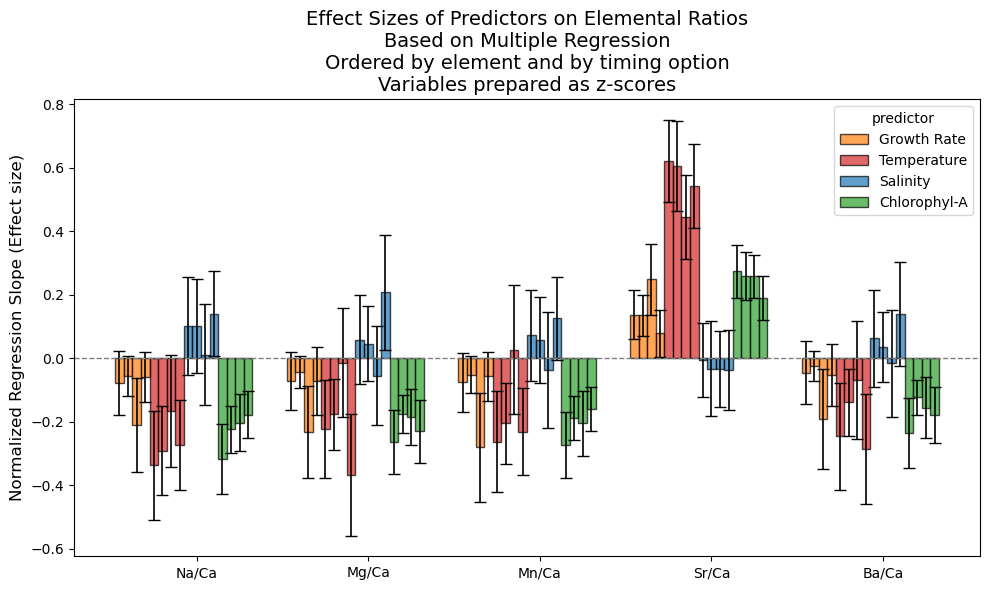

In [102]:
# Reshape the regression results to long format
# Use boolean indexing on the DataFrame column 'peakID' (not on a variable named peakID)
effect_sizes_summarized_z = regression_results_summarized_z[
    regression_results_summarized_z['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope', 'T_slope', 'S_slope', 'Chl_slope'],
    var_name='predictor',
    value_name='EffectSize'
)

# Reshape regression slope standard errors to long format
effect_sizes_summarized_z_se = regression_results_summarized_z[
    regression_results_summarized_z['peakID'] != 'All'
].melt(
    id_vars=['Element', 'peakID'],
    value_vars=['GR_slope_se', 'T_slope_se', 'S_slope_se', 'Chl_slope_se'],
    var_name='predictor',
    value_name='SE'
)

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# Ensure the predictors align for mapping and merging and give them recognizeable names
predictor_map = {
    'GR_slope': 'Growth Rate',
    'T_slope': 'Temperature',
    'S_slope': 'Salinity',
    'Chl_slope': 'Chlorophyl-A',
    'GR_slope_se': 'Growth Rate',
    'T_slope_se': 'Temperature',
    'S_slope_se': 'Salinity',
    'Chl_slope_se': 'Chlorophyl-A'
}
effect_sizes_summarized_z['predictor'] = effect_sizes_summarized_z['predictor'].map(predictor_map)
effect_sizes_summarized_z['peakID'] = effect_sizes_summarized_z['peakID'].astype(int)
effect_sizes_summarized_z_se['predictor'] = effect_sizes_summarized_z_se['predictor'].map(predictor_map)
effect_sizes_summarized_z_se['peakID'] = effect_sizes_summarized_z_se['peakID'].astype(int)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Merge effect sizes and standard errors
plot_data_z = pd.merge(effect_sizes_summarized_z, effect_sizes_summarized_z_se, on=['Element', 'predictor', 'peakID'])

# Plot with error bars
elements = plot_data_z['Element'].unique()
predictors = plot_data_z['predictor'].unique()
peakIDs = plot_data_z['peakID'].unique()

# Create an array of x locations for each group (Element)
x = np.arange(len(elements))

# Bar width
width_pred = 0.2
width = 0.05

# Define colors for each predictor display-name
predictor_colors = {
    'Growth Rate': '#ff7f0e', # orange
    'Temperature': '#d62728', # red
    'Salinity': '#1f77b4', # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each predictor as a separate set of bars
for i, predictor in enumerate(predictors):
    for j, peakID in enumerate(peakIDs): # loop over peakIDs
        # Subset data for this predictor
        df_sub = plot_data_z[(plot_data_z['predictor'] == predictor) & (plot_data_z['peakID'] == peakID)]
        # Ensure the rows align with the elements ordering so heights match the x positions
        df_sub = df_sub.set_index('Element').reindex(elements)

        valid_mask = ~np.isnan(df_sub['EffectSize'].values)
        
        # Align bar positions: offset each predictor
        positions = x + (i - 1.5) * width_pred + (j - 1.5) * width  # center around each element

        # map predictor to display name and pick a color
        display_name = predictor_map.get(predictor, predictor)
        color = predictor_colors.get(display_name, 'gray')  # fallback to gray if not found

        # Draw bars only for valid positions to avoid mismatched lengths
        if valid_mask.any():
            ax.bar(
                positions[valid_mask],
                df_sub['EffectSize'][valid_mask],
                width=width,
                label=display_name if j == 0 else None,  # label each predictor once (when j==0)
                yerr=df_sub['SE'][valid_mask],
                capsize=4,
                error_kw=dict(linewidth=1.2),
                color=color,
                alpha=0.7,
                edgecolor='black'
            )

# Add reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# X-axis labels centered under the grouped bars
ax.set_xticks(x + width * (len(predictors)-1) / 2)
ax.set_xticklabels(response_map.get(elem, elem) for elem in elements)

# Labels and title
ax.set_ylabel('Normalized Regression Slope (Effect size)', fontsize=12)
ax.set_title('Effect Sizes of Predictors on Elemental Ratios\nBased on Multiple Regression\nOrdered by element and by timing option\nVariables prepared as z-scores', fontsize=14)
ax.legend(title='predictor')

plt.tight_layout()
plt.show()

## LASSO (Least Absolute Shrinkage and Selection Operator) regression

### Performs variable selection and shrinks coefficients
Here applied on summarized data

In [103]:
# Define predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Store results
lasso_results = {}

# Standardize predictors once
X = data_intervals[predictors].values
X_scaled = StandardScaler().fit_transform(X)

# Loop over each response variable
for response in responses:
    y = data_intervals[response].values

    # Standardize response
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Drop rows with NaNs in either X or y
    valid_idx = ~np.isnan(X_scaled).any(axis=1) & ~np.isnan(y_scaled)
    X_valid = X_scaled[valid_idx]
    y_valid = y_scaled[valid_idx]

    if len(y_valid) < 5:
        print(f"Skipping {response} due to too few valid data points.")
        continue

    # Fit LASSO with cross-validation
    lasso = LassoCV(cv=5, random_state=0) # CV = 5 means 5-fold cross validation for parameter selection
    lasso.fit(X_valid, y_valid)

    # Save the coefficients
    coefs = pd.Series(lasso.coef_, index=predictors)

    # --- Post-LASSO uncertainty estimation---
    # Keep only non-zero coefficients
    selected = coefs[coefs != 0]

    if len(selected) == 0:
        lasso_results[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso.alpha_
        }
        continue

    # Post-LASSO: OLS on selected predictors
    selected_predictors = selected.index.tolist()
    X_postlasso = X_valid[:, [predictors.index(p) for p in selected_predictors]]
    X_postlasso_const = sm.add_constant(X_postlasso)
    ols_model = sm.OLS(y_valid, X_postlasso_const).fit()

    # Extract standard errors (excluding constant)
    se = ols_model.bse[1:]  # skip intercept

    # Store results
    lasso_results[response] = {
        'selected_predictors': selected_predictors,
        'coefficients': selected.values.tolist(),
        'standard_errors': se.tolist(),
        'alpha': lasso.alpha_
    }

# Display results
for response, res in lasso_results.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")


Response: NaCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.2685366321236055, 0.08783831313312135, -0.0842315884404612, -0.2251269585759692]
  Std. Errors (post-OLS): [0.07765424571624821, 0.07388848313819794, 0.04565806199132313, 0.042914399631616466]
  Best alpha (lambda): 0.0002

Response: MgCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.1937767789916822, 0.05803463556731856, -0.08459073948181797, -0.20884448943355555]
  Std. Errors (post-OLS): [0.0786327114655757, 0.07481949919989102, 0.046233366656600855, 0.043455133364913204]
  Best alpha (lambda): 0.0004

Response: MnCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.17555950996516573, 0.05265996993619226, -0.0930554543834151, -0.20305627997118836]
  Std. Errors (post-OLS): [0.0787865878070403, 0.07496591346683555, 0.04632384072498935, 0.043540170708983125]
 

### Visualize results of LASSO regression

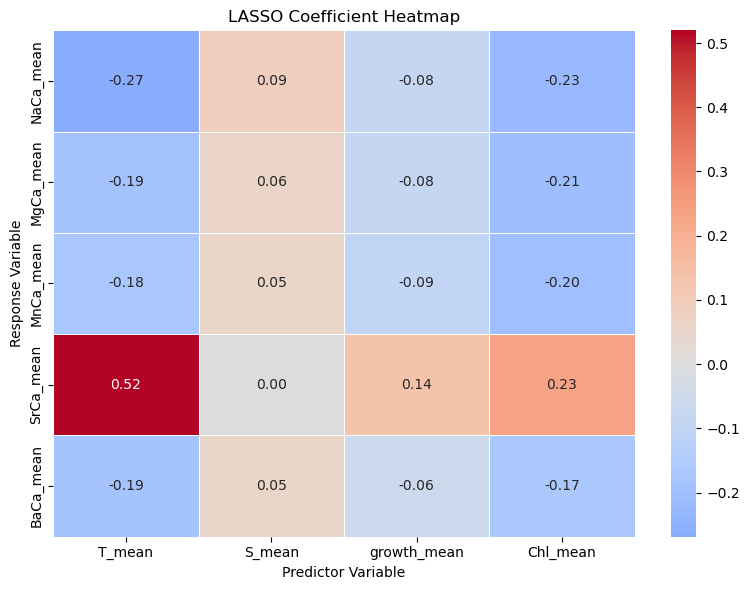

In [104]:
# Prepare coefficient matrix
# List of predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Initialize coefficient matrix (rows = responses, columns = predictors)
coef_matrix = pd.DataFrame(0.0, index=responses, columns=predictors)

# Fill with non-zero coefficients
for response, result in lasso_results.items():
    for pred, coef in zip(result['selected_predictors'], result['coefficients']):
        coef_matrix.loc[response, pred] = coef

# Plot heatmap of coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coef_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title("LASSO Coefficient Heatmap")
plt.ylabel("Response Variable")
plt.xlabel("Predictor Variable")
plt.tight_layout()
plt.show()

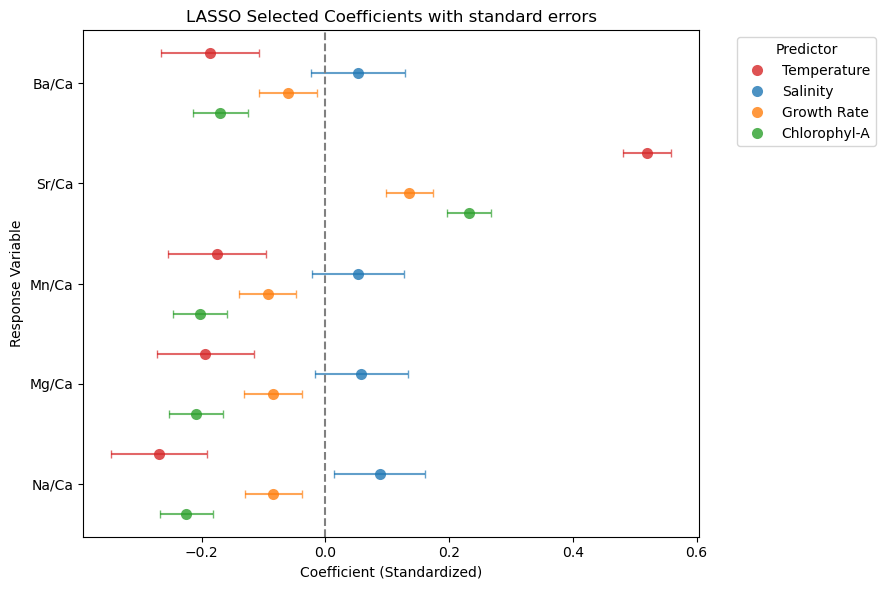

In [105]:
# Map the hue levels to the colors (make keys match your df_effects 'Predictor' hue values)
stripplot_palette = {
    'T_mean': predictor_colors['Temperature'],
    'S_mean': predictor_colors['Salinity'],
    'growth_mean': predictor_colors['Growth Rate'],
    'Chl_mean': predictor_colors['Chlorophyl-A'],
}

# Effect size plot
# Build long-format dataframe with coefficients and SEs
effect_data = []
for response, res in lasso_results.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })

df_effects = pd.DataFrame(effect_data)

# Sort responses for better plot layout (optional)
df_effects['Response'] = pd.Categorical(df_effects['Response'], categories=responses[::-1], ordered=True)


# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# apply the “neat” labels before plotting
df_effects['Response'] = df_effects['Response'].map(response_map)
df_effects['Predictor'] = df_effects['Predictor'].map(predictor_map)

# because we changed the predictor names, adjust the palette keys too
stripplot_palette = {predictor_map[k]: v for k, v in stripplot_palette.items()}

# now draw the strip‑plot with the nicer labels
plt.figure(figsize=(9, 6))
sns.stripplot(
    data=df_effects,
    x='Coefficient',
    y='Response',
    hue='Predictor',
    dodge=True,
    size=8,
    palette=stripplot_palette,
    alpha=0.8,
    hue_order=['Temperature', 'Salinity', 'Growth Rate', 'Chlorophyl-A']
)

# Add error bars manually
for i, row in df_effects.iterrows():
    y = df_effects['Response'].cat.categories.tolist().index(row['Response'])  # vertical position
    hue_offset = 0.2 * (['Temperature', 'Salinity', 'Growth Rate', 'Chlorophyl-A'].index(row['Predictor']) - 1.5)
    predictor = row['Predictor']  # e.g., 'T_mean', etc.
    color = stripplot_palette.get(predictor, 'gray')  # fallback color
    plt.errorbar(
        x=row['Coefficient'],
        y=y + hue_offset,
        xerr=row['SE'],
        fmt='none',
        ecolor=color,
        elinewidth=1.5,
        capsize=3,
        alpha=0.7
    )

plt.axvline(0, color='gray', linestyle='--')
plt.title("LASSO Selected Coefficients with standard errors")
plt.xlabel("Coefficient (Standardized)")
plt.ylabel("Response Variable")
plt.legend(title='Predictor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

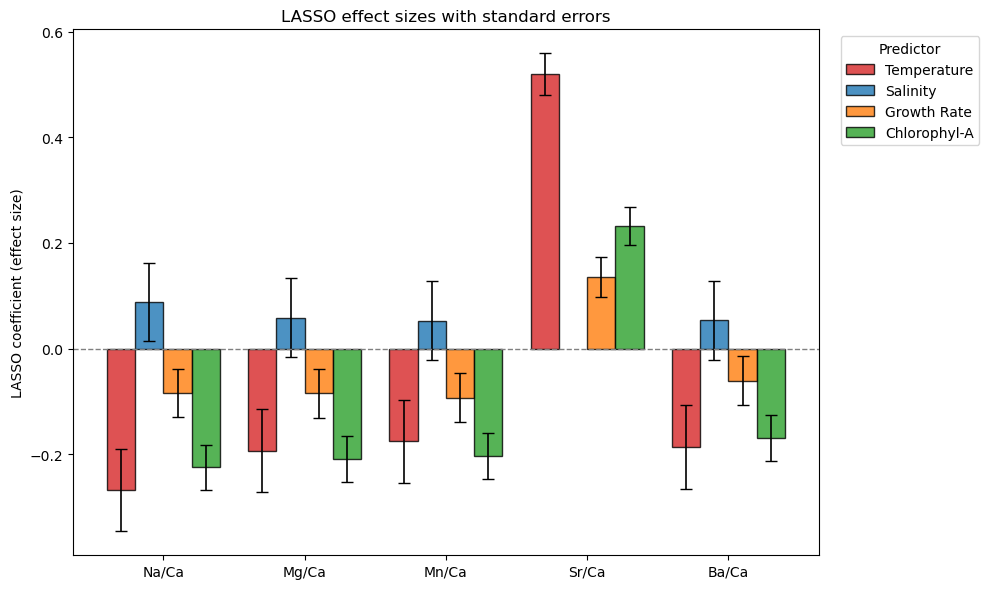

In [106]:
df = df_effects.copy()

# make sure the columns we need are present – df_effects
# has `Response`, `Coefficient` and `SE` rather than the
# generic names used in the original snippet
if 'Response' not in df.columns:
    df['Response'] = 'LASSO'
if 'Coefficient' not in df.columns:
    df['Coefficient'] = 0.0
if 'SE' not in df.columns:
    df['SE'] = 0.0

# rename to the names expected by the plotting loop
df = df.rename(columns={'Response': 'Element', 'Coefficient': 'Coef'})

# optional: map predictor names to nicer labels
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A',
    'GR_slope': 'Growth Rate',
    'T_slope': 'Temperature',
    'S_slope': 'Salinity',
    'Chl_slope': 'Chlorophyl-A'
}
df['Predictor'] = df['Predictor'].map(predictor_map).fillna(df['Predictor'])

# prepare plotting order
elements = df['Element'].unique()
predictors = df['Predictor'].unique()
x = np.arange(len(elements))
n_pred = len(predictors)
width = 0.8 / max(n_pred, 1)          # keep total group width ≤ 0.8

# colours for the predictors
predictor_colors = {
    'Growth Rate': '#ff7f0e',
    'Temperature': '#d62728',
    'Salinity': '#1f77b4',
    'Chlorophyl-A': '#2ca02c'
}

fig, ax = plt.subplots(figsize=(10, 6))

for i, pred in enumerate(predictors):
    subset = df[df['Predictor'] == pred] \
                .set_index('Element').reindex(elements).reset_index()
    positions = x - (width * (n_pred - 1) / 2) + i * width

    ax.bar(
        positions,
        subset['Coef'].values,
        width=width,
        label=pred,
        yerr=subset['SE'].values,
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=predictor_colors.get(pred, '#888888'),
        alpha=0.8,
        edgecolor='black'
    )

    # optional: mark significance if P_value column present
    if 'P_value' in subset.columns:
        for j, pv in enumerate(subset['P_value'].fillna(1.0)):
            if pv < 0.05:
                ax.annotate('*',
                            xy=(positions[j], subset['Coef'].values[j]),
                            ha='center', va='bottom',
                            fontsize=12, color='black')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([str(e) for e in elements], rotation=0)

ax.set_ylabel('LASSO coefficient (effect size)')
ax.set_title('LASSO effect sizes with standard errors')
ax.legend(title='Predictor', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Repeat LASSO regression on subtidal and intertidal datasets separately

In [107]:
# Define predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Store results
lasso_results_sub = {} # Results for subtidel dataset
lasso_results_int = {} # Results for intertidal dataset

# Standardize predictors once
data_sub = data_intervals[data_intervals['treatment'] == 'subtidal']
data_int = data_intervals[data_intervals['treatment'] == 'intertidal']
X_sub = data_sub[predictors].values
X_int = data_int[predictors].values
X_scaled_sub = StandardScaler().fit_transform(X_sub)
X_scaled_int = StandardScaler().fit_transform(X_int)

# Loop over each response variable
for response in responses:
    y_sub = data_sub[response].values
    y_int = data_int[response].values

    # Standardize response
    scaler_y = StandardScaler()
    y_sub_scaled = scaler_y.fit_transform(y_sub.reshape(-1, 1)).ravel()
    y_int_scaled = scaler_y.fit_transform(y_int.reshape(-1, 1)).ravel()

    # Drop rows with NaNs in either X or y
    valid_idx_sub = ~np.isnan(X_scaled_sub).any(axis=1) & ~np.isnan(y_sub_scaled)
    X_valid_sub = X_scaled_sub[valid_idx_sub]
    y_valid_sub = y_sub_scaled[valid_idx_sub]

    valid_idx_int = ~np.isnan(X_scaled_int).any(axis=1) & ~np.isnan(y_int_scaled)
    X_valid_int = X_scaled_int[valid_idx_int]
    y_valid_int = y_int_scaled[valid_idx_int]

    # Fit LASSO with cross-validation
    lasso_sub = LassoCV(cv=5, random_state=0) # CV = 5 means 5-fold cross validation for parameter selection
    lasso_int = LassoCV(cv=5, random_state=0)
    lasso_sub.fit(X_valid_sub, y_valid_sub)
    lasso_int.fit(X_valid_int, y_valid_int)

    # Save the coefficients
    coefs_sub = pd.Series(lasso_sub.coef_, index=predictors)
    coefs_int = pd.Series(lasso_int.coef_, index=predictors)

    # --- Post-LASSO uncertainty estimation---
    # Keep only non-zero coefficients
    selected_sub = coefs_sub[coefs_sub != 0]
    selected_int = coefs_int[coefs_int != 0]

    if len(selected_sub) == 0:
        lasso_results_sub[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso_sub.alpha_
        }
        continue

    if len(selected_int) == 0:
        lasso_results_int[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso_int.alpha_
        }
        continue

    # Post-LASSO: OLS on selected predictors
    selected_predictors_sub = selected_sub.index.tolist()
    selected_predictors_int = selected_int.index.tolist()
    X_sub_postlasso = X_valid_sub[:, [predictors.index(p) for p in selected_predictors_sub]]
    X_int_postlasso = X_valid_int[:, [predictors.index(p) for p in selected_predictors_int]]
    X_sub_postlasso_const = sm.add_constant(X_sub_postlasso)
    X_int_postlasso_const = sm.add_constant(X_int_postlasso)
    ols_model_sub = sm.OLS(y_valid_sub, X_sub_postlasso_const).fit()
    ols_model_int = sm.OLS(y_valid_int, X_int_postlasso_const).fit()

    # Extract standard errors (excluding constant)
    se_sub = ols_model_sub.bse[1:]  # skip intercept
    se_int = ols_model_int.bse[1:]  # skip intercept

    # Store results
    lasso_results_sub[response] = {
        'selected_predictors': selected_predictors_sub,
        'coefficients': selected_sub.values.tolist(),
        'standard_errors': se_sub.tolist(),
        'alpha': lasso_sub.alpha_
    }
    lasso_results_int[response] = {
        'selected_predictors': selected_predictors_int,
        'coefficients': selected_int.values.tolist(),
        'standard_errors': se_int.tolist(),
        'alpha': lasso_int.alpha_
    }

# Display results
print("Subtidal LASSO Results:")
for response, res in lasso_results_sub.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")
print("\nIntertidal LASSO Results:")
for response, res in lasso_results_int.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")

Subtidal LASSO Results:

Response: NaCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.2990812225018216, 0.12039231350143284, -0.09690859152785063, -0.24485265906362783]
  Std. Errors (post-OLS): [0.09910254005802727, 0.09236128904389779, 0.05820130022602908, 0.05307664989776885]
  Best alpha (lambda): 0.0002

Response: MgCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.26184567806737263, 0.128894055985713, -0.09433585420613705, -0.23207120821305585]
  Std. Errors (post-OLS): [0.10015139654835303, 0.09333879918048787, 0.0588172764810446, 0.05363838917001583]
  Best alpha (lambda): 0.0005

Response: MnCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.1968565228737367, 0.08500456202121044, -0.11280404299248288, -0.22959845086420044]
  Std. Errors (post-OLS): [0.10055432269260034, 0.09371431708396824, 0.05905390841274406, 

### Visualize results of LASSO regression for subtidal and intertidal data

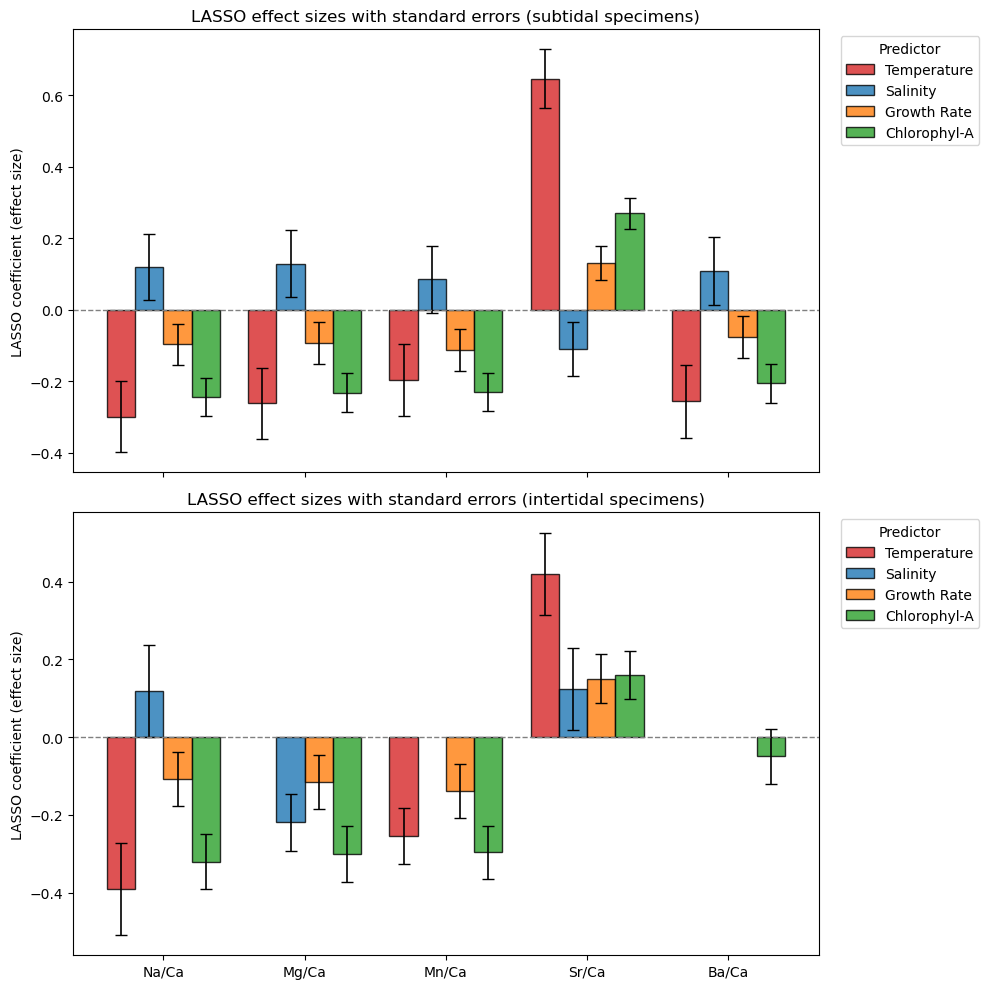

In [108]:
# Effect size plot
# Build long-format dataframe with coefficients and SEs
effect_data_sub = []
for response, res in lasso_results_sub.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data_sub.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })
effect_data_int = []
for response, res in lasso_results_int.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data_int.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })

df_effects_sub = pd.DataFrame(effect_data_sub)
df_effects_int = pd.DataFrame(effect_data_int)

# Sort responses for better plot layout (optional)
df_effects_sub['Response'] = pd.Categorical(df_effects_sub['Response'], categories=responses[::-1], ordered=True)
df_effects_int['Response'] = pd.Categorical(df_effects_int['Response'], categories=responses[::-1], ordered=True)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# apply the “neat” labels before plotting
df_effects_sub['Response'] = df_effects_sub['Response'].map(response_map)
df_effects_sub['Predictor'] = df_effects_sub['Predictor'].map(predictor_map)

df_effects_int['Response'] = df_effects_int['Response'].map(response_map)
df_effects_int['Predictor'] = df_effects_int['Predictor'].map(predictor_map)

# Set removed predictors to zero for plotting (optional, depends on how you want to handle them)
if 'Response' not in df_effects_sub.columns:
    df_effects_sub['Response'] = 'LASSO'
if 'Response' not in df_effects_int.columns:
    df_effects_int['Response'] = 'LASSO'
if 'Coefficient' not in df_effects_sub.columns:
    df_effects_sub['Coefficient'] = 0.0
if 'Coefficient' not in df_effects_int.columns:
    df_effects_int['Coefficient'] = 0.0
if 'SE' not in df_effects_sub.columns:
    df_effects_sub['SE'] = 0.0
if 'SE' not in df_effects_int.columns:
    df_effects_int['SE'] = 0.0

# rename to the names expected by the plotting loop
df_effects_sub = df_effects_sub.rename(columns={'Response': 'Element', 'Coefficient': 'Coef'})
df_effects_int = df_effects_int.rename(columns={'Response': 'Element', 'Coefficient': 'Coef'})

# prepare plotting order
elements = df_effects_sub['Element'].unique()
predictors = df_effects_sub['Predictor'].unique()
x = np.arange(len(elements))
n_pred = len(predictors)
width = 0.8 / max(n_pred, 1)          # keep total group width ≤ 0.8

# colours for the predictors
predictor_colors = {
    'Growth Rate': '#ff7f0e',
    'Temperature': '#d62728',
    'Salinity': '#1f77b4',
    'Chlorophyl-A': '#2ca02c'
}

# make two stacked panels, share the x‑axis
fig, (ax_sub, ax_int) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
# you can use `ax = ax_sub` for the first block of plotting,
# then switch to `ax = ax_int` when you draw the intertidal panel

for i, pred in enumerate(predictors):
    subset_sub = df_effects_sub[df_effects_sub['Predictor'] == pred] \
                .set_index('Element').reindex(elements).reset_index()
    subset_int = df_effects_int[df_effects_int['Predictor'] == pred] \
                .set_index('Element').reindex(elements).reset_index()
    positions = x - (width * (n_pred - 1) / 2) + i * width

    ax_sub.bar(
        positions,
        subset_sub['Coef'].values,
        width=width,
        label=pred,
        yerr=subset_sub['SE'].values,
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=predictor_colors.get(pred, '#888888'),
        alpha=0.8,
        edgecolor='black'
    )
    ax_int.bar(
        positions,
        subset_int['Coef'].values,
        width=width,
        label=pred,
        yerr=subset_int['SE'].values,
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=predictor_colors.get(pred, '#888888'),
        alpha=0.8,
        edgecolor='black'
    )

    # optional: mark significance if P_value column present
    if 'P_value' in subset_sub.columns:
        for j, pv in enumerate(subset_sub['P_value'].fillna(1.0)):
            if pv < 0.05:
                ax_sub.annotate('*',
                            xy=(positions[j], subset_sub['Coef'].values[j]),
                            ha='center', va='bottom',
                            fontsize=12, color='black')
    if 'P_value' in subset_int.columns:
        for j, pv in enumerate(subset_int['P_value'].fillna(1.0)):
            if pv < 0.05:
                ax_int.annotate('*',
                            xy=(positions[j], subset_int['Coef'].values[j]),
                            ha='center', va='bottom',
                            fontsize=12, color='black')
                
ax_sub.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_int.axhline(0, color='gray', linestyle='--', linewidth=1)

ax_sub.set_xticks(x)
ax_sub.set_xticklabels([str(e) for e in elements], rotation=0)
ax_int.set_xticks(x)
ax_int.set_xticklabels([str(e) for e in elements], rotation=0)

ax_sub.set_ylabel('LASSO coefficient (effect size)')
ax_int.set_ylabel('LASSO coefficient (effect size)')
ax_sub.set_title('LASSO effect sizes with standard errors (subtidal specimens)')
ax_int.set_title('LASSO effect sizes with standard errors (intertidal specimens)')
ax_sub.legend(title='Predictor', bbox_to_anchor=(1.02, 1), loc='upper left')
ax_int.legend(title='Predictor', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Repeat LASSO regression on dataset excluding the most difficult to identify specimens

In [109]:
# Define predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Store results
lasso_results_select = {} # Results for subtidel dataset

# Standardize predictors once
data_select = data_intervals[~data_intervals["specimen"].isin(bad_specimens)]
X_select = data_select[predictors].values
X_scaled_select = StandardScaler().fit_transform(X_select)

# Loop over each response variable
for response in responses:
    y_select = data_select[response].values

    # Standardize response
    scaler_y = StandardScaler()
    y_select_scaled = scaler_y.fit_transform(y_select.reshape(-1, 1)).ravel()

    # Drop rows with NaNs in either X or y
    valid_idx_select = ~np.isnan(X_scaled_select).any(axis=1) & ~np.isnan(y_select_scaled)
    X_valid_select = X_scaled_select[valid_idx_select]
    y_valid_select = y_select_scaled[valid_idx_select]

    # Fit LASSO with cross-validation
    lasso_select = LassoCV(cv=5, random_state=0) # CV = 5 means 5-fold cross validation for parameter selection
    lasso_select.fit(X_valid_select, y_valid_select)

    # Save the coefficients
    coefs_select = pd.Series(lasso_select.coef_, index=predictors)

    # --- Post-LASSO uncertainty estimation---
    # Keep only non-zero coefficients
    selected_select = coefs_select[coefs_select != 0]

    if len(selected_select) == 0:
        lasso_results_select[response] = {
            'selected_predictors': [],
            'coefficients': [],
            'standard_errors': [],
            'alpha': lasso_select.alpha_
        }
        continue

    # Post-LASSO: OLS on selected predictors
    selected_predictors_select = selected_select.index.tolist()
    X_select_postlasso = X_valid_select[:, [predictors.index(p) for p in selected_predictors_select]]
    X_select_postlasso_const = sm.add_constant(X_select_postlasso)
    ols_model_select = sm.OLS(y_valid_select, X_select_postlasso_const).fit()

    # Extract standard errors (excluding constant)
    se_select = ols_model_select.bse[1:]  # skip intercept

    # Store results
    lasso_results_select[response] = {
        'selected_predictors': selected_predictors_select,
        'coefficients': selected_select.values.tolist(),
        'standard_errors': se_select.tolist(),
        'alpha': lasso_select.alpha_
    }

# Display results
print("LASSO results ignoring specimens with challenging peakID:")
for response, res in lasso_results_select.items():
    print(f"\nResponse: {response}")
    if res['selected_predictors']:
        print(f"  Selected predictors: {res['selected_predictors']}")
        print(f"  Coefficients:        {res['coefficients']}")
        print(f"  Std. Errors (post-OLS): {res['standard_errors']}")
        print(f"  Best alpha (lambda): {res['alpha']:.4f}")
    else:
        print("  No predictors selected.")

LASSO results ignoring specimens with challenging peakID:

Response: NaCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.22153058977216578, 0.046116758954754346, -0.1049581705943605, -0.2062491053260597]
  Std. Errors (post-OLS): [0.09689019627733554, 0.0921685235317538, 0.057619391864838256, 0.05446532911808685]
  Best alpha (lambda): 0.0006

Response: MgCa_mean
  Selected predictors: ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.11157140148656142, -0.01006556104622261, -0.09710082054320093, -0.18420493517845854]
  Std. Errors (post-OLS): [0.0981951102738674, 0.0934098461940797, 0.05839540795113934, 0.05519886639040768]
  Best alpha (lambda): 0.0082

Response: MnCa_mean
  Selected predictors: ['T_mean', 'growth_mean', 'Chl_mean']
  Coefficients:        [-0.10120303997816014, -0.10784183398637602, -0.17556246111634355]
  Std. Errors (post-OLS): [0.05974928052904779, 0.058054742042791194, 0.055032439345

### Visualize results of LASSO regression for subtidal and intertidal data

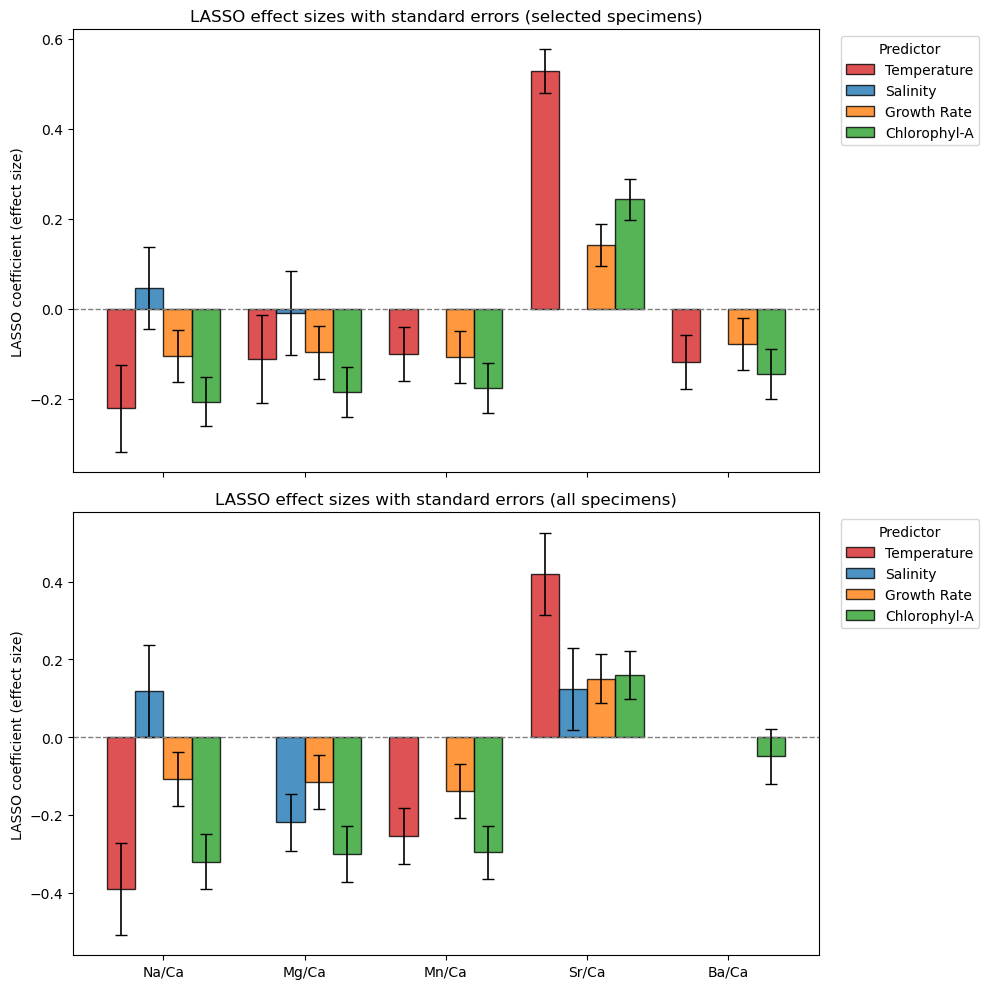

In [110]:
# Effect size plot
# Build long-format dataframe with coefficients and SEs
effect_data_select = []
for response, res in lasso_results_select.items():
    for pred, coef, se in zip(res['selected_predictors'], res['coefficients'], res['standard_errors']):
        effect_data_select.append({
            'Response': response,
            'Predictor': pred,
            'Coefficient': coef,
            'SE': se
        })

df_effects_select = pd.DataFrame(effect_data_select)

# Sort responses for better plot layout (optional)
df_effects_select['Response'] = pd.Categorical(df_effects_select['Response'], categories=responses[::-1], ordered=True)

# Neat names for responses
response_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Neat names for predictors
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# apply the “neat” labels before plotting
df_effects_select['Response'] = df_effects_select['Response'].map(response_map)
df_effects_select['Predictor'] = df_effects_select['Predictor'].map(predictor_map)

# Set removed predictors to zero for plotting (optional, depends on how you want to handle them)
if 'Response' not in df_effects_select.columns:
    df_effects_select['Response'] = 'LASSO'
if 'Coefficient' not in df_effects_select.columns:
    df_effects_select['Coefficient'] = 0.0
if 'SE' not in df_effects_select.columns:
    df_effects_select['SE'] = 0.0

# rename to the names expected by the plotting loop
df_effects_select = df_effects_select.rename(columns={'Response': 'Element', 'Coefficient': 'Coef'})
df_effects = df_effects_int.rename(columns={'Response': 'Element', 'Coefficient': 'Coef'}) # reuse the intertidal results for the "all specimens" panel

# prepare plotting order
elements = df_effects_select['Element'].unique()
predictors = df_effects_select['Predictor'].unique()
x = np.arange(len(elements))
n_pred = len(predictors)
width = 0.8 / max(n_pred, 1)          # keep total group width ≤ 0.8

# colours for the predictors
predictor_colors = {
    'Growth Rate': '#ff7f0e',
    'Temperature': '#d62728',
    'Salinity': '#1f77b4',
    'Chlorophyl-A': '#2ca02c'
}

# make two stacked panels, share the x‑axis
fig, (ax_select, ax_all) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
# you can use `ax = ax_select` for the first block of plotting,
# then switch to `ax = ax_all` when you draw the intertidal panel

for i, pred in enumerate(predictors):
    subset_select = df_effects_select[df_effects_select['Predictor'] == pred] \
                .set_index('Element').reindex(elements).reset_index()
    subset_all = df_effects[df_effects['Predictor'] == pred] \
                .set_index('Element').reindex(elements).reset_index()
    positions = x - (width * (n_pred - 1) / 2) + i * width

    ax_select.bar(
        positions,
        subset_select['Coef'].values,
        width=width,
        label=pred,
        yerr=subset_select['SE'].values,
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=predictor_colors.get(pred, '#888888'),
        alpha=0.8,
        edgecolor='black'
    )
    ax_all.bar(
        positions,
        subset_all['Coef'].values,
        width=width,
        label=pred,
        yerr=subset_all['SE'].values,
        capsize=4,
        error_kw=dict(linewidth=1.2),
        color=predictor_colors.get(pred, '#888888'),
        alpha=0.8,
        edgecolor='black'
    )

    # optional: mark significance if P_value column present
    if 'P_value' in subset_select.columns:
        for j, pv in enumerate(subset_select['P_value'].fillna(1.0)):
            if pv < 0.05:
                ax_select.annotate('*',
                            xy=(positions[j], subset_select['Coef'].values[j]),
                            ha='center', va='bottom',
                            fontsize=12, color='black')
    if 'P_value' in subset_all.columns:
        for j, pv in enumerate(subset_all['P_value'].fillna(1.0)):
            if pv < 0.05:
                ax_all.annotate('*',
                            xy=(positions[j], subset_all['Coef'].values[j]),
                            ha='center', va='bottom',
                            fontsize=12, color='black')
                
ax_select.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_all.axhline(0, color='gray', linestyle='--', linewidth=1)

ax_select.set_xticks(x)
ax_select.set_xticklabels([str(e) for e in elements], rotation=0)
ax_all.set_xticks(x)
ax_all.set_xticklabels([str(e) for e in elements], rotation=0)

ax_select.set_ylabel('LASSO coefficient (effect size)')
ax_all.set_ylabel('LASSO coefficient (effect size)')
ax_select.set_title('LASSO effect sizes with standard errors (selected specimens)')
ax_all.set_title('LASSO effect sizes with standard errors (all specimens)')
ax_select.legend(title='Predictor', bbox_to_anchor=(1.02, 1), loc='upper left')
ax_all.legend(title='Predictor', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Variance decomposition using stepwise linear modelling

### Load data on analytical uncertainty from duplicates

In [111]:
TE_uncertainty = pd.read_csv('TE_duplicate_reproducibility_results.csv')
TE_uncertainty = TE_uncertainty.pivot(index='specimen', columns='element', values='combined_std_dev') # Widen the dataframe so that each TE is a separate column
print(TE_uncertainty)
TE_uncertainty.to_csv('TE_uncertainty_by_specimen.csv')

element   138Ba/43Ca  23Na/43Ca  25Mg/43Ca  55Mn/43Ca  88Sr/43Ca
specimen                                                        
B255_int    0.000053   0.318381   0.010586   0.000098   0.036856
B323_int    0.000140   0.530184   0.090630   0.000707   0.037834
B325_int    0.000086   0.231112   0.042046   0.000206   0.031119
G652_sub    0.000178   0.371893   0.021213   0.000427   0.049665
G664_sub    0.000314   0.325924   0.272455   0.000979   0.024674
G668_sub    0.000080   0.314423   0.011833   0.000198   0.023788
G691_int    0.000049   0.273692   0.011458   0.000202   0.021877
G717_sub    0.000091   0.299042   0.030424   0.000221   0.062278
G719_int    0.000103   1.343050   0.018131   0.000353   0.039243
G723_sub    0.000065   0.548404   0.029226   0.000621   0.038418
G728_int    0.000060   0.400513   0.013170   0.000338   0.019565
G730_sub    0.000096   0.307477   0.024175   0.000402   0.048005
G732_sub    0.000112   0.332336   0.022782   0.000166   0.041468
G737_sub    0.000781   1.

### Stepwise York regression + R-squared for variance decomposition

In [112]:
# Define predictors and responses
predictors = ['T_mean', 'S_mean', 'growth_mean', 'Chl_mean']
responses = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']

# Create mapping to translate response variable names to the corresponding standard deviation column names
response_map = {
    'NaCa_mean': '23Na/43Ca',
    'MgCa_mean': '25Mg/43Ca',
    'MnCa_mean': '55Mn/43Ca',
    'SrCa_mean': '88Sr/43Ca',
    'BaCa_mean': '138Ba/43Ca'
}

# (keep the scalers around if you need them later)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Loop through elemental ratios and decompose the variance explained by each predictor
variance_decomposition = pd.DataFrame(0.0, index=responses, columns=predictors)
variance_decomposition['Analytical uncertainty'] = 0.0  # Add column for analytical uncertainty
variance_decomposition['Unexplained'] = 0.0  # Add column for unexplained variance
variance_decomposition['variability within intervals'] = 0.0  # Add column for variability within intervals

for response in responses:
    variance = 1.0  # total variance placeholder

    # order predictors by the absolute value of the LASSO coefficient
    lasso_results[response]['selected_predictors'] = sorted(
        lasso_results[response]['selected_predictors'],
        key=lambda p: abs(
            lasso_results[response]['coefficients'][
                lasso_results[response]['selected_predictors'].index(p)
            ]
        ),
        reverse=True
    )
    print(f"Ordered predictors for {response}: "
          f"{lasso_results[response]['selected_predictors']}")

    y = data_intervals[response] # Extract response variable values
    y_sd = data_intervals[response.replace('_mean', '_sd')] # Extract response variable standard deviations

    # Calculate the contribution of variability within intervals to the variance
    variance_decomposition.loc[response, 'variability within intervals'] = np.mean(y_sd)**2 / np.var(y)
    print(f"variability within intervals contribution for {response}: {variance_decomposition.loc[response, 'variability within intervals']}")

    for pred in lasso_results[response]['selected_predictors']:
        print(f"Calculating contribution of {pred} to {response}...")

        x = data_intervals[pred]

        # drop rows with missing values
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        if len(x_clean) < 2:
            print("  not enough data, skipping.")
            continue

        # simple linear regression (OLS) instead of ODR
        X_design = sm.add_constant(x_clean)
        ols_res = sm.OLS(y_clean, X_design).fit()
        coef = ols_res.params[1]      # slope
        se = ols_res.bse[1]           # standard error of slope
        # print(f"OLS coefficient for {pred}: {coef}, SE: {se}")

        # Compute the contribution of this predictor to the variance explained using R²
        variance_decomposition.loc[response, pred] = ols_res.rsquared
        # Compute the remaining variance after accounting for this predictor
        variance -= ols_res.rsquared
        # Calculate the residuals after accounting for this predictor
        y = ols_res.resid
        print(f"Remaining variance after accounting for {pred}: {variance}")

    # Add variance caused by analytical uncertainty calculated from duplicate measurements
    if response_map[response] in TE_uncertainty.columns:
        analytical_uncertainty = np.mean(TE_uncertainty[response_map[response]])
        variance_decomposition.loc[response, 'Analytical uncertainty'] = analytical_uncertainty**2 / np.var(y)

    # Store the unexplained variance after accounting for all selected predictors
    variance_decomposition.loc[response, 'Unexplained'] = variance

# End result:
print(variance_decomposition)
variance_decomposition.to_csv('Variance_decomposition.csv', index=False)

Ordered predictors for NaCa_mean: ['T_mean', 'Chl_mean', 'S_mean', 'growth_mean']
variability within intervals contribution for NaCa_mean: 0.07676864931647731
Calculating contribution of T_mean to NaCa_mean...
Remaining variance after accounting for T_mean: 0.9693683812570226
Calculating contribution of Chl_mean to NaCa_mean...
Remaining variance after accounting for Chl_mean: 0.9191655322925579
Calculating contribution of S_mean to NaCa_mean...
Remaining variance after accounting for S_mean: 0.9190214677466947
Calculating contribution of growth_mean to NaCa_mean...
Remaining variance after accounting for growth_mean: 0.9092680235568698
Ordered predictors for MgCa_mean: ['Chl_mean', 'T_mean', 'growth_mean', 'S_mean']
variability within intervals contribution for MgCa_mean: 0.2631317458625641
Calculating contribution of Chl_mean to MgCa_mean...
Remaining variance after accounting for Chl_mean: 0.9704499143896831
Calculating contribution of T_mean to MgCa_mean...
Remaining variance after

C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\3081226899.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_res.params[1]      # slope
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\3081226899.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se = ols_res.bse[1]           # standard error of slope
C:\Users\nwi213\AppData\Local\Temp\ipykernel_2768\3081226899.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

### Plot variance decomposition per element

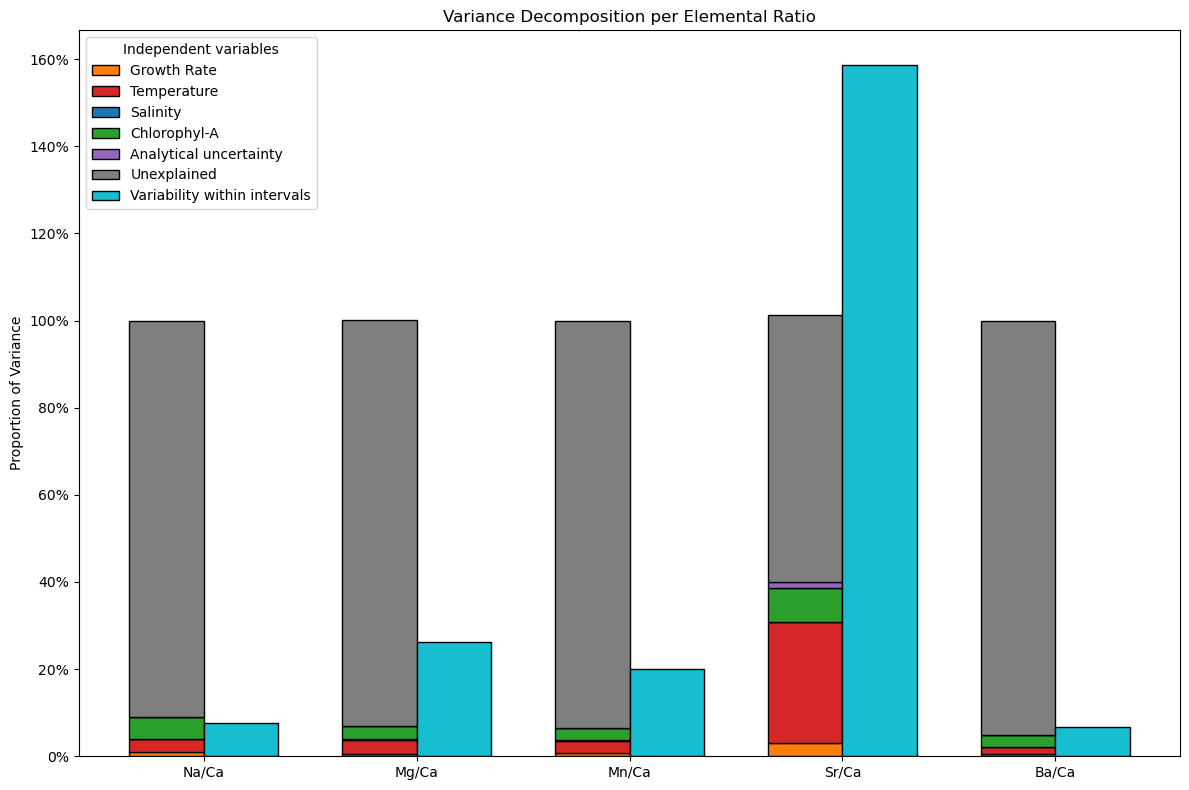

In [113]:
# Map element names to nice labels
element_map = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Map predictor names to nice labels
predictor_map = {
    'growth_mean': 'Growth Rate',
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'Chl_mean': 'Chlorophyl-A'
}

# Define colors for predictors
predictor_colors = {
    'Growth Rate': '#ff7f0e',  # orange
    'Temperature': '#d62728',  # red
    'Salinity': '#1f77b4',    # blue
    'Chlorophyl-A': '#2ca02c' # green
}

# Additional colors for other components
other_colors = {
    'Analytical uncertainty': '#9467bd',  # purple
    'Unexplained': '#7f7f7f'  # gray
}

# Prepare data for plotting
elements = list(variance_decomposition.index)
components = ['growth_mean', 'T_mean', 'S_mean', 'Chl_mean', 'Analytical uncertainty', 'Unexplained']
variability = 'variability within intervals'

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Width of bars
bar_width = 0.35
x = range(len(elements))

# For each element, plot stacked bar for main components
bottom = [0] * len(elements)
for comp in components:
    if comp in predictor_map:
        label = predictor_map[comp]
        color = predictor_colors[label]
    else:
        label = comp
        color = other_colors.get(comp, 'gray')
    
    values = variance_decomposition.loc[elements, comp].values
    ax.bar(x, values, bottom=bottom, width=bar_width, label=label, color=color, edgecolor='black')
    bottom = [b + v for b, v in zip(bottom, values)]

# Plot 'variability within intervals' as a separate bar next to each
variability_values = variance_decomposition.loc[elements, variability].values
ax.bar([i + bar_width for i in x], variability_values, width=bar_width, label='Variability within intervals', color='#17becf', edgecolor='black')  # cyan color

# Set x-ticks and labels
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels([element_map.get(elem, elem) for elem in elements])

# Labels and title
ax.set_ylabel('Proportion of Variance')
ax.set_title('Variance Decomposition per Elemental Ratio')
ax.legend(title = 'Independent variables', loc='upper left', bbox_to_anchor=(0, 1))

# Convert y-axis to percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## Errors of reverse prediction

### Switch dependent and independent variables to calculate possible prediction of environmental variables